
# Detecting Low-Frequency Network Attacks in Imbalanced Public Network Traffic Datasets

## End-to-End UREC/SHUREC7-Aligned Machine-Learning Pipeline

**Dataset:** UNSW-NB15  
**Primary target:** `attack_cat` (Normal + nine attack categories)  
**Research design:** Secondary-data-only, multiclass machine-learning experiment  
**Primary analytical concern:** Detecting low-frequency attack classes without creating an unacceptable false-alarm burden.

### Ethics and scope guardrails

This notebook is intentionally restricted to the existing UNSW-NB15 public academic dataset.

It does **not**:
- capture live network traffic;
- probe, scan, exploit, or attack any system;
- access private organisational networks;
- recruit human participants;
- attempt to identify people, organisations, device owners, or real networks;
- republish the raw dataset.

The notebook produces an **analytical prototype**, not a deployable intrusion-detection application.

### Important methodological choices

1. The multiclass field `attack_cat` is the target.
2. The binary `label` field is dropped from predictors because it directly reveals whether a row is Normal or Attack and would contaminate the multiclass task.
3. The official/predesignated train and test files are preserved.
4. A validation split is created **only from the official training file** for model selection.
5. All preprocessing is fitted only on development/training data.
6. Any over-sampling or under-sampling is placed inside an `imblearn` pipeline so it occurs only during model fitting.
7. The official test set is not used for model selection.
8. Accuracy is reported, but model comparison prioritises **macro-F1**, **balanced accuracy**, **per-class recall/F1**, **precision-recall behaviour**, and low-frequency-class performance.
9. Arbitrary outlier deletion is avoided because extreme network-flow values may be genuine attack signals.
10. Reproducibility controls include fixed seeds, a central configuration, saved metrics, saved figures, and an environment manifest.

### Why the earlier binary/RNN approach is not used here

The research problem concerns **rare multiclass attack categories**, not only the binary `label`. In addition, treating tabular flow features as an artificial RNN sequence does not correspond to a real temporal sequence in these prepared UNSW-NB15 feature files. This notebook therefore uses tabular classifiers that are more defensible for the stated research question.


In [52]:
# 1. Imports, reproducibility, and project configuration

from __future__ import annotations

import json
import math
import os
import platform
import random
import sys
import time
import warnings
from copy import deepcopy
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import sklearn

from IPython.display import Markdown, display
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import BalancedRandomForestClassifier

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Project configuration
PROJECT_TITLE = "Detecting Low-Frequency Network Attacks in Imbalanced Public Network Traffic Datasets"

# Kaggle input root. The notebook searches recursively, so the dataset slug can vary.
KAGGLE_INPUT_ROOT = Path("/kaggle/input")

OUTPUT_DIRECTORY = Path("/kaggle/working/unsw_nb15_low_frequency_attack_project")
FIGURE_DIRECTORY = OUTPUT_DIRECTORY / "figures"

TRAIN_FILE_NAME = "UNSW_NB15_training-set.parquet"
TEST_FILE_NAME = "UNSW_NB15_testing-set.parquet"

TARGET_COLUMN = "attack_cat"
BINARY_LABEL_COLUMN = "label"

VALIDATION_SIZE = 0.20

# Classes below this prevalence in the official training split are treated as low-frequency.
RARE_CLASS_PREVALENCE_THRESHOLD = 0.02

# Resampling limits are applied only inside the training pipeline.
OVER_SAMPLE_MIN_COUNT = 2_000
UNDER_SAMPLE_MAX_COUNT = 20_000

RUN_XGBOOST_IF_AVAILABLE = True
SAVE_FINAL_MODEL = True
MAX_FEATURE_IMPORTANCE_ROWS = 25

# Credibility and sensitivity controls
RUN_DEDUPLICATED_SENSITIVITY = True
SAVE_DUPLICATE_AUDIT = True

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(PROJECT_TITLE)
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Output directory: {OUTPUT_DIRECTORY}")

Detecting Low-Frequency Network Attacks in Imbalanced Public Network Traffic Datasets
Python: 3.12.13
pandas: 2.3.3
scikit-learn: 1.6.1
Output directory: /kaggle/working/unsw_nb15_low_frequency_attack_project



## 2. Dataset loading

The Kaggle version described for this project uses prepared Parquet files. The notebook first tries the exact file names shown in the dataset. If those names differ slightly in a later Kaggle version, it performs a conservative filename search inside `/kaggle/input/unswnb15`.

The official train/test designation is preserved even if the file sizes appear unusual.


In [53]:
# 2. Locate and load the official UNSW-NB15 train and test files

def list_kaggle_input_files(input_root: Path) -> list[Path]:
    """Return all files currently mounted under the Kaggle input directory."""
    if not input_root.exists():
        raise FileNotFoundError(
            f"Kaggle input directory does not exist: {input_root}. "
            "Make sure this notebook is running in Kaggle."
        )

    return sorted(path for path in input_root.rglob("*") if path.is_file())


def locate_unsw_file(
    input_root: Path,
    exact_file_name: str,
    required_keywords: tuple[str, ...],
) -> Path:
    """Find a UNSW-NB15 file anywhere under /kaggle/input."""
    exact_matches = list(input_root.rglob(exact_file_name))

    if exact_matches:
        return sorted(exact_matches)[0]

    all_files = list_kaggle_input_files(input_root)

    fallback_matches = [
        path
        for path in all_files
        if path.suffix.lower() in {".parquet", ".csv"}
        and all(keyword.lower() in path.name.lower() for keyword in required_keywords)
        and "unsw" in path.name.lower()
    ]

    if fallback_matches:
        return sorted(fallback_matches)[0]

    preview = "\n".join(str(path) for path in all_files[:100])

    raise FileNotFoundError(
        f"Could not locate {exact_file_name} anywhere under {input_root}.\n"
        f"Files currently visible to Kaggle include:\n{preview}"
    )


def read_dataset_table(file_path: Path) -> pd.DataFrame:
    """Read either Parquet or CSV without changing the source data."""
    suffix = file_path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(file_path)

    if suffix == ".csv":
        return pd.read_csv(file_path)

    raise ValueError(f"Unsupported dataset format: {suffix}")


all_kaggle_files = list_kaggle_input_files(KAGGLE_INPUT_ROOT)

print(f"Files detected under /kaggle/input: {len(all_kaggle_files)}")
for visible_path in all_kaggle_files[:30]:
    print(visible_path)

train_file_path = locate_unsw_file(
    KAGGLE_INPUT_ROOT,
    TRAIN_FILE_NAME,
    required_keywords=("training", "set"),
)

test_file_path = locate_unsw_file(
    KAGGLE_INPUT_ROOT,
    TEST_FILE_NAME,
    required_keywords=("testing", "set"),
)

DATASET_DIRECTORY = train_file_path.parent

official_train_df = read_dataset_table(train_file_path)
official_test_df = read_dataset_table(test_file_path)

print("\nDataset detected successfully.")
print(f"Dataset directory: {DATASET_DIRECTORY}")
print(f"Training file: {train_file_path}")
print(f"Testing file: {test_file_path}")
print(f"Official training shape: {official_train_df.shape}")
print(f"Official testing shape: {official_test_df.shape}")

display(official_train_df.head())

Files detected under /kaggle/input: 2
/kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_testing-set.parquet
/kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_training-set.parquet

Dataset detected successfully.
Dataset directory: /kaggle/input/datasets/dhoogla/unswnb15
Training file: /kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_training-set.parquet
Testing file: /kaggle/input/datasets/dhoogla/unswnb15/UNSW_NB15_testing-set.parquet
Official training shape: (175341, 36)
Official testing shape: (82332, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [54]:
# 3. Schema, missingness, duplicates, and target-integrity audit

def dataframe_audit(dataframe: pd.DataFrame, name: str) -> pd.DataFrame:
    audit_rows = []
    for column_name in dataframe.columns:
        series = dataframe[column_name]
        audit_rows.append(
            {
                "dataset": name,
                "column": column_name,
                "dtype": str(series.dtype),
                "missing_count": int(series.isna().sum()),
                "missing_pct": float(series.isna().mean() * 100),
                "n_unique": int(series.nunique(dropna=False)),
            }
        )
    return pd.DataFrame(audit_rows)


assert TARGET_COLUMN in official_train_df.columns, f"Missing target column: {TARGET_COLUMN}"
assert TARGET_COLUMN in official_test_df.columns, f"Missing target column: {TARGET_COLUMN}"

train_class_set = set(official_train_df[TARGET_COLUMN].astype(str).unique())
test_class_set = set(official_test_df[TARGET_COLUMN].astype(str).unique())
unseen_test_classes = sorted(test_class_set - train_class_set)

if unseen_test_classes:
    raise ValueError(f"Test contains classes absent from training data: {unseen_test_classes}")

schema_audit_df = pd.concat(
    [
        dataframe_audit(official_train_df, "official_train"),
        dataframe_audit(official_test_df, "official_test"),
    ],
    ignore_index=True,
)

print("Columns:")
print(list(official_train_df.columns))
print()
print(f"Exact duplicate rows in official training file: {official_train_df.duplicated().sum():,}")
print(f"Exact duplicate rows in official testing file : {official_test_df.duplicated().sum():,}")
print(f"Total missing cells in training: {official_train_df.isna().sum().sum():,}")
print(f"Total missing cells in testing : {official_test_df.isna().sum().sum():,}")

display(schema_audit_df.head(15))

# Check whether binary 'label' is a deterministic proxy for attack_cat.
if BINARY_LABEL_COLUMN in official_train_df.columns:
    inferred_binary = (official_train_df[TARGET_COLUMN].astype(str).str.lower() != "normal").astype(int)
    agreement = (inferred_binary.to_numpy() == official_train_df[BINARY_LABEL_COLUMN].astype(int).to_numpy()).mean()
    print(f"\nAgreement between '{BINARY_LABEL_COLUMN}' and Normal-vs-Attack derived from '{TARGET_COLUMN}': {agreement:.4%}")
    if agreement > 0.999:
        print(
            f"Leakage safeguard: '{BINARY_LABEL_COLUMN}' will NOT be used as a predictor for the multiclass target."
        )

Columns:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']

Exact duplicate rows in official training file: 78,519
Exact duplicate rows in official testing file : 32,361
Total missing cells in training: 0
Total missing cells in testing : 0


,dataset,column,dtype,missing_count,missing_pct,n_unique
0,official_train,dur,float32,0,0.0,74039
1,official_train,proto,category,0,0.0,133
2,official_train,service,category,0,0.0,13
3,official_train,state,category,0,0.0,9
4,official_train,spkts,int16,0,0.0,480
5,official_train,dpkts,int16,0,0.0,443
6,official_train,sbytes,int32,0,0.0,7214
7,official_train,dbytes,int32,0,0.0,6660
8,official_train,rate,float32,0,0.0,76794
9,official_train,sload,float32,0,0.0,80885



Agreement between 'label' and Normal-vs-Attack derived from 'attack_cat': 100.0000%
Leakage safeguard: 'label' will NOT be used as a predictor for the multiclass target.



## 4. Duplicate and cross-split overlap credibility audit

UNSW-NB15 contains many repeated rows in the prepared files. Repeated observations are not automatically evidence of invalid research because repeated flow patterns can occur naturally and the Kaggle version has also removed some contaminating features. However, exact overlap between predefined training and testing records can make a benchmark appear easier than genuinely unseen data.

The notebook therefore performs a transparent, hash-based exact-value audit at three levels:

- exact duplicates within the official training file;
- exact duplicates within the official testing file;
- predictor-vector and predictor-plus-target overlap from training into testing.

The official train/test evaluation is retained for comparability with the supplied benchmark split. A later sensitivity section also evaluates the selected model on test subsets that exclude exact train/test signature overlap. These checks are treated as **credibility and robustness analysis**, not as evidence that the original dataset is ethically or methodologically invalid.


,audit_measure,count,denominator,percentage
0,Exact duplicate rows within official training ...,78519,175341,44.781
1,Exact duplicate rows within official testing file,32361,82332,39.305
2,Testing rows with predictor vector also presen...,20851,82332,25.326
3,Testing rows with identical predictor-plus-tar...,18596,82332,22.587
4,Testing rows retained after removing train/tes...,63736,82332,77.413
5,Unique testing rows retained after removing tr...,48400,82332,58.786


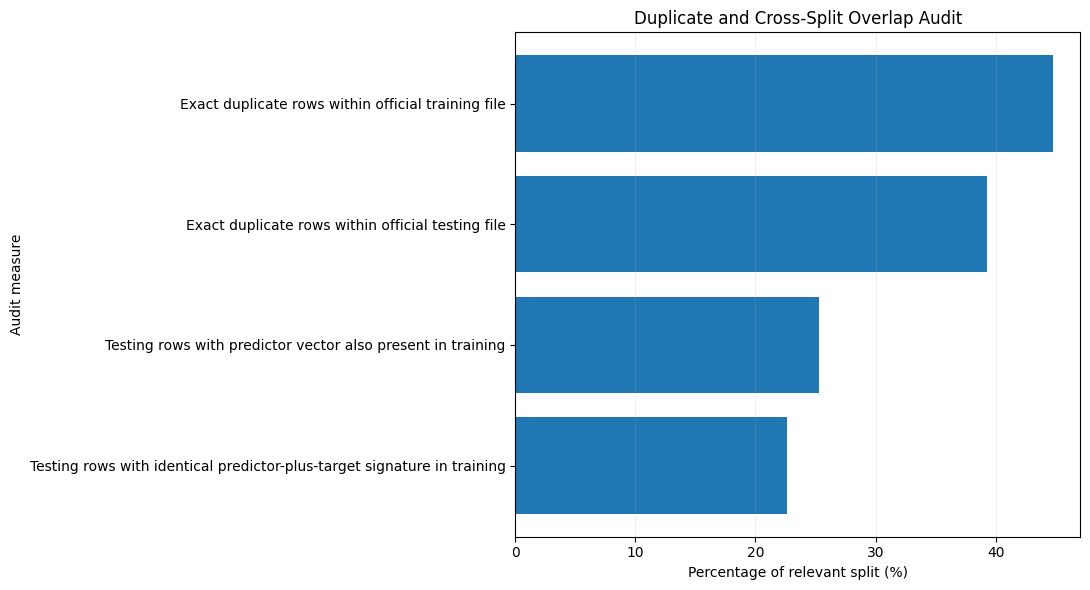

Official training unique predictor-plus-target signatures: 96,822 / 175,341
Official testing rows with no identical train signature: 63,736 / 82,332
Strict unique and overlap-free testing rows: 48,400 / 82,332


In [55]:
# 4. Duplicate and cross-split overlap credibility audit

def stable_row_hash(dataframe: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Create a stable row-level hash for exact-value overlap auditing."""
    audit_frame = dataframe.loc[:, columns].copy()

    # Convert categorical/object fields to strings so train/test category metadata
    # cannot affect equality hashing.
    for column_name in audit_frame.select_dtypes(
        include=["object", "category", "string"]
    ).columns:
        audit_frame[column_name] = audit_frame[column_name].astype("string").fillna("<MISSING>")

    return pd.util.hash_pandas_object(
        audit_frame,
        index=False,
        categorize=True,
    ).astype("uint64")


audit_predictor_columns = [
    column_name
    for column_name in official_train_df.columns
    if column_name not in {TARGET_COLUMN, BINARY_LABEL_COLUMN}
]

audit_signature_columns = audit_predictor_columns + [TARGET_COLUMN]

train_predictor_hash = stable_row_hash(
    official_train_df,
    audit_predictor_columns,
)
test_predictor_hash = stable_row_hash(
    official_test_df,
    audit_predictor_columns,
)

train_full_signature_hash = stable_row_hash(
    official_train_df,
    audit_signature_columns,
)
test_full_signature_hash = stable_row_hash(
    official_test_df,
    audit_signature_columns,
)

unique_train_predictor_hashes = np.unique(train_predictor_hash.to_numpy())
unique_train_signature_hashes = np.unique(train_full_signature_hash.to_numpy())

cross_split_predictor_overlap_mask = np.isin(
    test_predictor_hash.to_numpy(),
    unique_train_predictor_hashes,
)

cross_split_same_signature_mask = np.isin(
    test_full_signature_hash.to_numpy(),
    unique_train_signature_hashes,
)

train_unique_signature_mask = ~pd.Series(
    train_full_signature_hash.to_numpy()
).duplicated(keep="first").to_numpy()

test_unique_signature_mask = ~pd.Series(
    test_full_signature_hash.to_numpy()
).duplicated(keep="first").to_numpy()

overlap_free_test_mask = ~cross_split_same_signature_mask
strict_unique_overlap_free_test_mask = (
    overlap_free_test_mask & test_unique_signature_mask
)

duplicate_overlap_audit_rows = [
    {
        "audit_measure": "Exact duplicate rows within official training file",
        "count": int(official_train_df.duplicated().sum()),
        "denominator": int(len(official_train_df)),
    },
    {
        "audit_measure": "Exact duplicate rows within official testing file",
        "count": int(official_test_df.duplicated().sum()),
        "denominator": int(len(official_test_df)),
    },
    {
        "audit_measure": "Testing rows with predictor vector also present in training",
        "count": int(cross_split_predictor_overlap_mask.sum()),
        "denominator": int(len(official_test_df)),
    },
    {
        "audit_measure": "Testing rows with identical predictor-plus-target signature in training",
        "count": int(cross_split_same_signature_mask.sum()),
        "denominator": int(len(official_test_df)),
    },
    {
        "audit_measure": "Testing rows retained after removing train/test signature overlap",
        "count": int(overlap_free_test_mask.sum()),
        "denominator": int(len(official_test_df)),
    },
    {
        "audit_measure": "Unique testing rows retained after removing train/test signature overlap",
        "count": int(strict_unique_overlap_free_test_mask.sum()),
        "denominator": int(len(official_test_df)),
    },
]

duplicate_overlap_audit_df = pd.DataFrame(duplicate_overlap_audit_rows)
duplicate_overlap_audit_df["percentage"] = (
    duplicate_overlap_audit_df["count"]
    / duplicate_overlap_audit_df["denominator"]
    * 100
)

display(duplicate_overlap_audit_df.round(3))

if SAVE_DUPLICATE_AUDIT:
    duplicate_overlap_audit_df.to_csv(
        OUTPUT_DIRECTORY / "duplicate_cross_split_overlap_audit.csv",
        index=False,
    )

figure, axis = plt.subplots(figsize=(11, 6))
plot_df = duplicate_overlap_audit_df.iloc[:4].sort_values(
    "percentage",
    ascending=True,
)
axis.barh(plot_df["audit_measure"], plot_df["percentage"])
axis.set_title("Duplicate and Cross-Split Overlap Audit")
axis.set_xlabel("Percentage of relevant split (%)")
axis.set_ylabel("Audit measure")
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
figure.savefig(
    FIGURE_DIRECTORY / "04_duplicate_cross_split_overlap_audit.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(
    f"Official training unique predictor-plus-target signatures: "
    f"{train_unique_signature_mask.sum():,} / {len(train_unique_signature_mask):,}"
)
print(
    f"Official testing rows with no identical train signature: "
    f"{overlap_free_test_mask.sum():,} / {len(overlap_free_test_mask):,}"
)
print(
    f"Strict unique and overlap-free testing rows: "
    f"{strict_unique_overlap_free_test_mask.sum():,} / "
    f"{len(strict_unique_overlap_free_test_mask):,}"
)

In [56]:
# 4. Class-frequency analysis and operational definition of "rare"

train_class_counts = (
    official_train_df[TARGET_COLUMN]
    .astype(str)
    .value_counts()
    .rename_axis("attack_class")
    .reset_index(name="count")
)

train_class_counts["prevalence"] = train_class_counts["count"] / len(official_train_df)
train_class_counts["prevalence_pct"] = train_class_counts["prevalence"] * 100
train_class_counts["is_low_frequency"] = (
    train_class_counts["prevalence"] < RARE_CLASS_PREVALENCE_THRESHOLD
)

rare_class_names = (
    train_class_counts.loc[train_class_counts["is_low_frequency"], "attack_class"]
    .sort_values()
    .tolist()
)

print(f"Low-frequency threshold: < {RARE_CLASS_PREVALENCE_THRESHOLD:.1%} of official training rows")
print(f"Low-frequency classes detected: {rare_class_names}")

display(train_class_counts)

Low-frequency threshold: < 2.0% of official training rows
Low-frequency classes detected: ['Analysis', 'Backdoor', 'Shellcode', 'Worms']


,attack_class,count,prevalence,prevalence_pct,is_low_frequency
0,Normal,56000,0.319378,31.937767,False
1,Generic,40000,0.228127,22.812691,False
2,Exploits,33393,0.190446,19.044605,False
3,Fuzzers,18184,0.103706,10.370649,False
4,DoS,12264,0.069944,6.994371,False
5,Reconnaissance,10491,0.059832,5.983198,False
6,Analysis,2000,0.011406,1.140635,True
7,Backdoor,1746,0.009958,0.995774,True
8,Shellcode,1133,0.006462,0.646169,True
9,Worms,130,0.000741,0.074141,True


In [57]:
# 5. EDA Figure 1 — Official training class distribution

plot_df = train_class_counts.sort_values("count", ascending=True)

fig = px.bar(
    plot_df,
    x="count",
    y="attack_class",
    orientation="h",
    text="count",
    title="UNSW-NB15 Official Training Class Distribution",
    labels={"count": "Number of records", "attack_class": "Attack class"},
    template="plotly_white",
)
fig.update_layout(height=550)
fig.show()
fig.write_html(FIGURE_DIRECTORY / "01_training_class_distribution.html")

In [58]:
# 6. EDA Figure 2 — Training vs testing class proportions

def class_proportion_table(dataframe: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = dataframe[TARGET_COLUMN].astype(str).value_counts()
    proportions = counts / counts.sum()
    return pd.DataFrame(
        {
            "attack_class": counts.index,
            "count": counts.values,
            "proportion_pct": proportions.values * 100,
            "split": split_name,
        }
    )


split_distribution_df = pd.concat(
    [
        class_proportion_table(official_train_df, "Official training"),
        class_proportion_table(official_test_df, "Official testing"),
    ],
    ignore_index=True,
)

fig = px.bar(
    split_distribution_df,
    x="attack_class",
    y="proportion_pct",
    barmode="group",
    facet_row="split",
    title="Train–Test Class-Proportion Comparison",
    labels={"attack_class": "Class", "proportion_pct": "Share of split (%)"},
    template="plotly_white",
)
fig.update_xaxes(tickangle=35)
fig.update_layout(height=750)
fig.show()
fig.write_html(FIGURE_DIRECTORY / "02_train_test_class_proportions.html")

In [59]:
# 7. EDA Figure 3 — Rare-class prevalence

rare_prevalence_df = train_class_counts.copy()
rare_prevalence_df["frequency_group"] = np.where(
    rare_prevalence_df["is_low_frequency"],
    f"Low-frequency (<{RARE_CLASS_PREVALENCE_THRESHOLD:.0%})",
    "Other classes",
)

fig = px.scatter(
    rare_prevalence_df,
    x="prevalence_pct",
    y="count",
    size="count",
    hover_name="attack_class",
    symbol="frequency_group",
    title="Class Prevalence and Support",
    labels={"prevalence_pct": "Training prevalence (%)", "count": "Training records"},
    template="plotly_white",
    log_y=True,
)
fig.show()
fig.write_html(FIGURE_DIRECTORY / "03_class_prevalence_support.html")

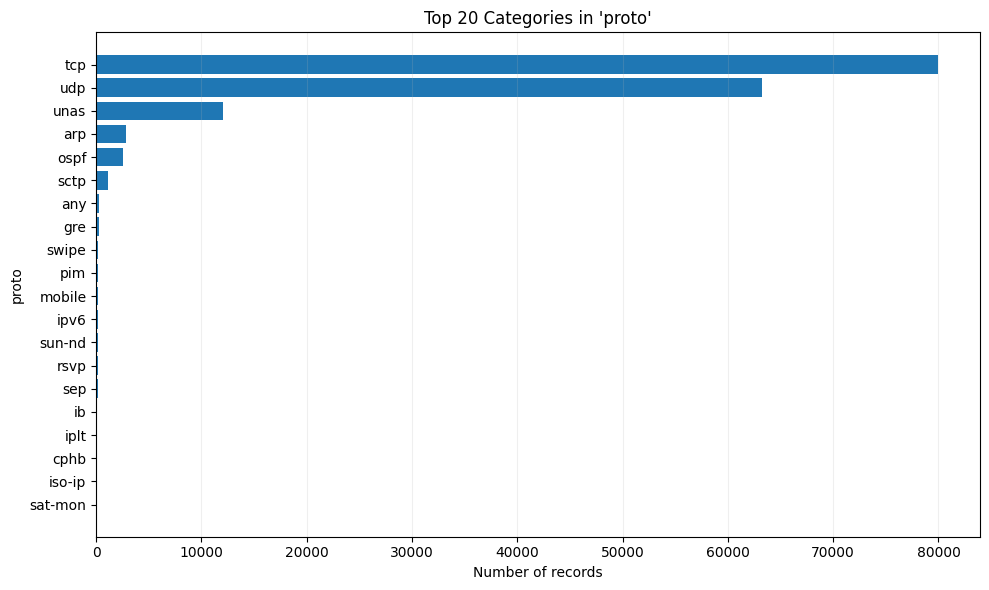

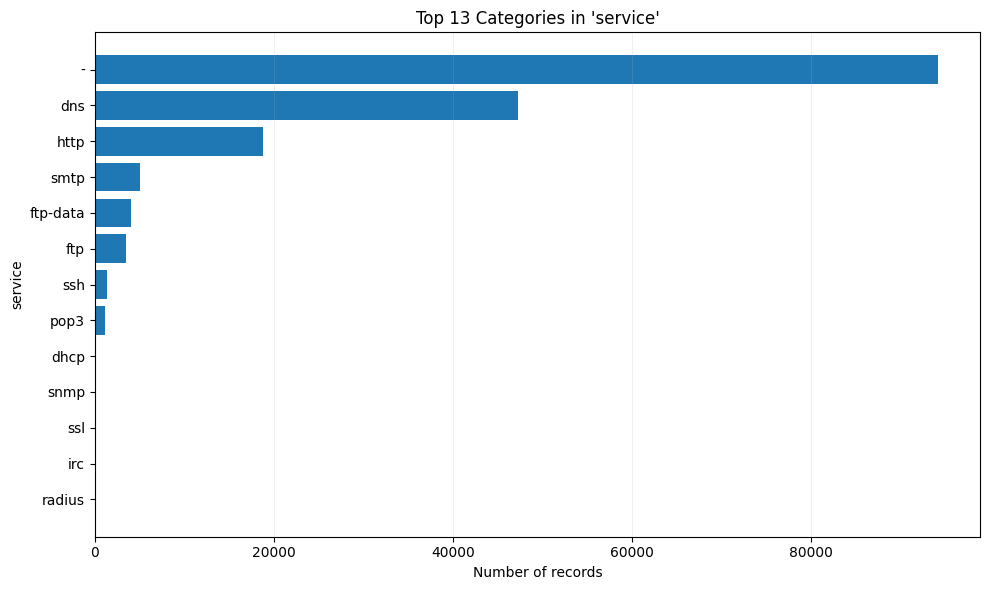

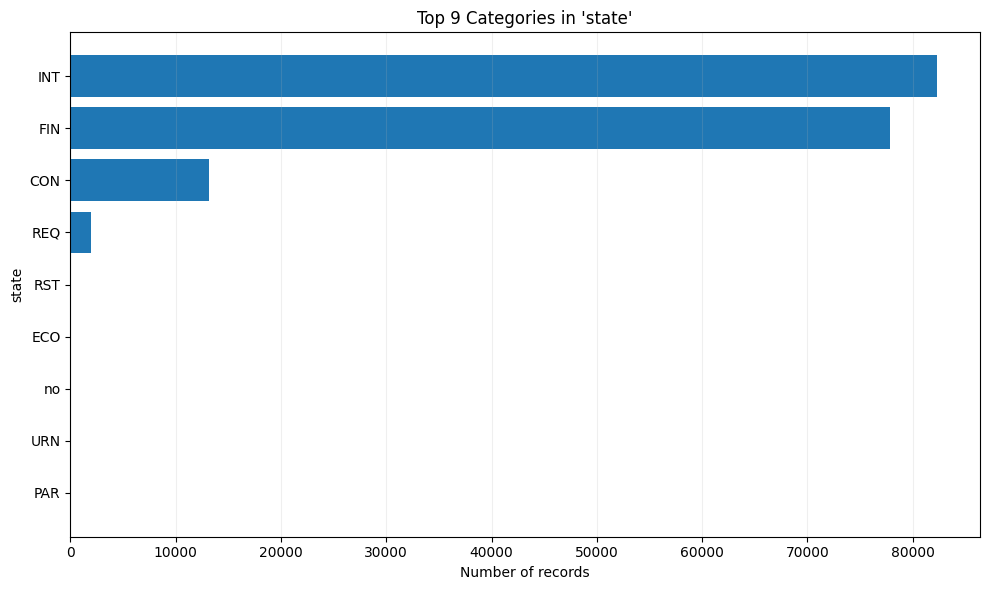

In [60]:
# 8. EDA Figures 4–6 — Categorical feature profiles

categorical_candidates = [
    column for column in ["proto", "service", "state"]
    if column in official_train_df.columns
]

for figure_index, column_name in enumerate(categorical_candidates, start=4):
    top_counts = (
        official_train_df[column_name]
        .astype(str)
        .value_counts()
        .head(20)
        .sort_values(ascending=True)
    )

    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh(top_counts.index, top_counts.values)
    axis.set_title(f"Top {len(top_counts)} Categories in '{column_name}'")
    axis.set_xlabel("Number of records")
    axis.set_ylabel(column_name)
    axis.grid(axis="x", alpha=0.2)
    figure.tight_layout()
    figure.savefig(
        FIGURE_DIRECTORY / f"{figure_index:02d}_{column_name}_top_categories.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

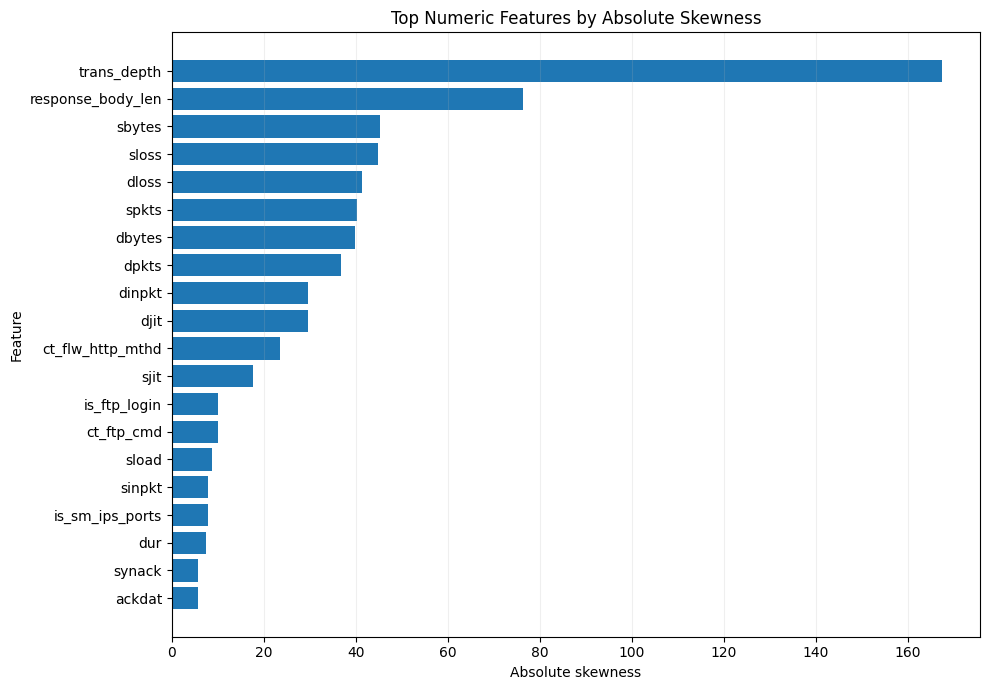

In [61]:
# 9. EDA Figure 7 — Numeric feature skewness

predictor_columns_for_audit = [
    column for column in official_train_df.columns
    if column not in {TARGET_COLUMN, BINARY_LABEL_COLUMN}
]

numeric_columns_for_audit = (
    official_train_df[predictor_columns_for_audit]
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

numeric_skewness = (
    official_train_df[numeric_columns_for_audit]
    .skew(numeric_only=True)
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

figure, axis = plt.subplots(figsize=(10, 7))
axis.barh(numeric_skewness.index[::-1], numeric_skewness.values[::-1])
axis.set_title("Top Numeric Features by Absolute Skewness")
axis.set_xlabel("Absolute skewness")
axis.set_ylabel("Feature")
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "07_numeric_feature_skewness.png", dpi=180, bbox_inches="tight")
plt.show()

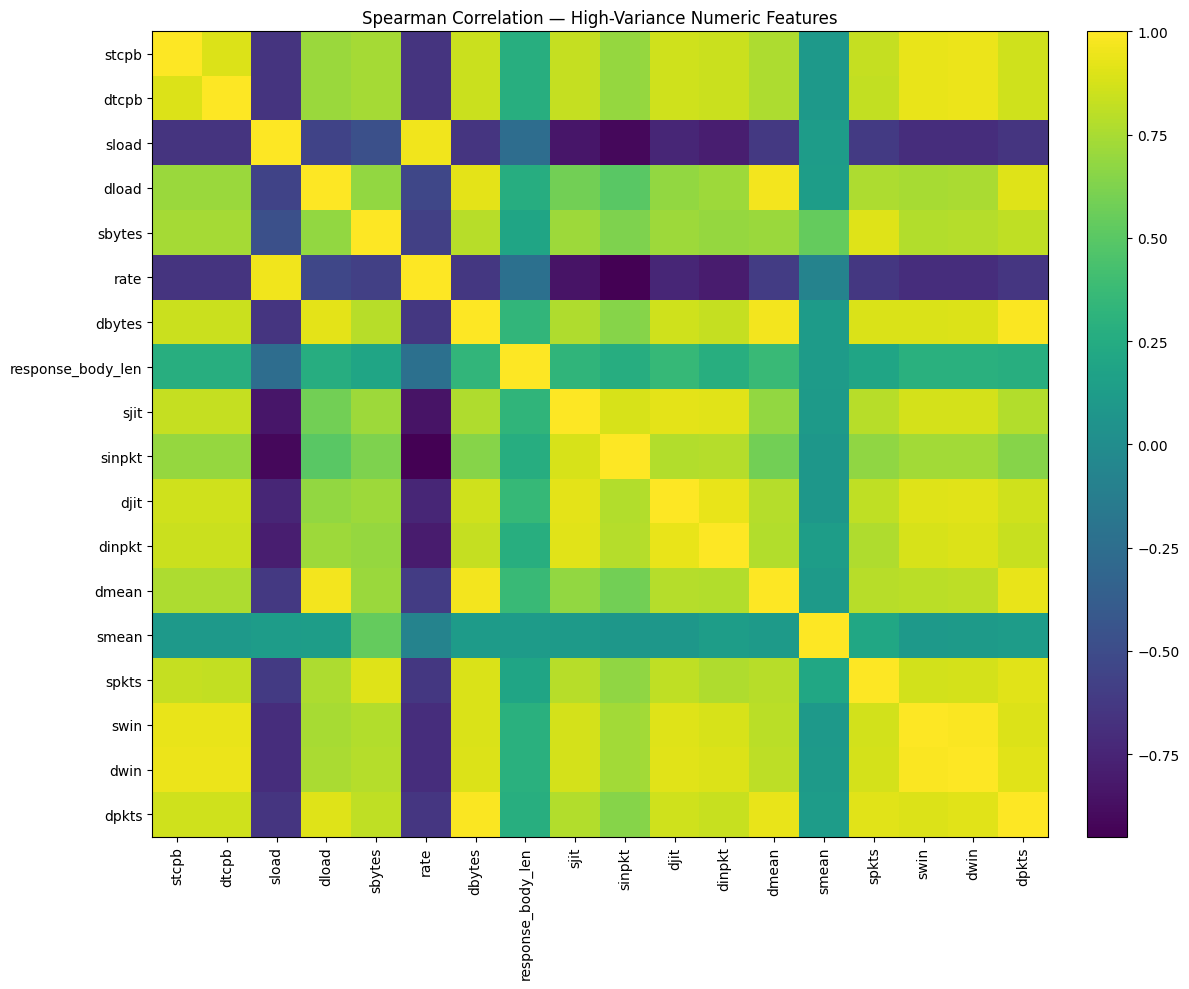

In [62]:
# 10. EDA Figure 8 — Correlation heatmap of informative numeric features

# Select numeric variables with the highest variance after replacing inf values.
numeric_audit_df = (
    official_train_df[numeric_columns_for_audit]
    .replace([np.inf, -np.inf], np.nan)
)

variance_rank = numeric_audit_df.var(numeric_only=True).sort_values(ascending=False)
top_numeric_for_correlation = variance_rank.head(min(18, len(variance_rank))).index.tolist()

correlation_matrix = numeric_audit_df[top_numeric_for_correlation].corr(method="spearman")

figure, axis = plt.subplots(figsize=(12, 10))
image = axis.imshow(correlation_matrix.to_numpy(), aspect="auto")
axis.set_xticks(np.arange(len(top_numeric_for_correlation)))
axis.set_yticks(np.arange(len(top_numeric_for_correlation)))
axis.set_xticklabels(top_numeric_for_correlation, rotation=90)
axis.set_yticklabels(top_numeric_for_correlation)
axis.set_title("Spearman Correlation — High-Variance Numeric Features")
figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "08_numeric_spearman_correlation.png", dpi=180, bbox_inches="tight")
plt.show()


## 11. Data preparation and leakage control

### Predictor selection
`attack_cat` is the multiclass outcome. `label` is excluded from predictors because it is a near-deterministic Normal-vs-Attack indicator.

### Missing/infinite values
The current Kaggle Parquet version is expected to contain no missing values, but the pipeline still includes imputers for reproducibility and robustness. Infinite values are converted to `NaN` before modelling.

### Categorical variables
Categorical predictors are one-hot encoded with `handle_unknown="ignore"` so categories that appear only in validation/test data do not break inference.

### Numeric variables
Numeric predictors use median imputation and `RobustScaler`. No test-set statistics are used to fit the scaler.

### Why arbitrary outlier removal is avoided
Very large values in network-traffic features can be real properties of malicious traffic. Removing rows simply because a value appears extreme could remove the exact minority behaviour the project is trying to detect.


In [63]:
# 11. Build clean predictor/target datasets

def sanitize_infinite_values(dataframe: pd.DataFrame) -> pd.DataFrame:
    sanitized = dataframe.copy()
    numeric_columns = sanitized.select_dtypes(include=np.number).columns
    sanitized[numeric_columns] = sanitized[numeric_columns].replace([np.inf, -np.inf], np.nan)
    return sanitized


drop_from_predictors = [TARGET_COLUMN]
if BINARY_LABEL_COLUMN in official_train_df.columns:
    drop_from_predictors.append(BINARY_LABEL_COLUMN)

official_train_features_df = sanitize_infinite_values(
    official_train_df.drop(columns=drop_from_predictors)
)
official_test_features_df = sanitize_infinite_values(
    official_test_df.drop(columns=drop_from_predictors)
)

official_train_target_raw = official_train_df[TARGET_COLUMN].astype(str)
official_test_target_raw = official_test_df[TARGET_COLUMN].astype(str)

target_encoder = LabelEncoder()
official_train_target = target_encoder.fit_transform(official_train_target_raw)
official_test_target = target_encoder.transform(official_test_target_raw)

class_names = target_encoder.classes_.tolist()
class_name_to_index = {name: index for index, name in enumerate(class_names)}
class_index_to_name = {index: name for name, index in class_name_to_index.items()}

rare_class_indices = [
    class_name_to_index[class_name]
    for class_name in rare_class_names
    if class_name in class_name_to_index
]

print(f"Predictor count before encoding: {official_train_features_df.shape[1]}")
print(f"Classes ({len(class_names)}): {class_names}")
print(f"Rare-class indices: {rare_class_indices}")

Predictor count before encoding: 34
Classes (10): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
Rare-class indices: [0, 1, 8, 9]


In [64]:
# 12. Development/validation split — created ONLY from official training data

(
    development_features_df,
    validation_features_df,
    development_target,
    validation_target,
) = train_test_split(
    official_train_features_df,
    official_train_target,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED,
    stratify=official_train_target,
)

print(f"Development shape: {development_features_df.shape}")
print(f"Validation shape : {validation_features_df.shape}")
print(f"Official test shape remains untouched: {official_test_features_df.shape}")

development_class_counts = pd.Series(development_target).value_counts().sort_index()
validation_class_counts = pd.Series(validation_target).value_counts().sort_index()

split_support_df = pd.DataFrame(
    {
        "class_index": range(len(class_names)),
        "attack_class": class_names,
        "development_count": [development_class_counts.get(index, 0) for index in range(len(class_names))],
        "validation_count": [validation_class_counts.get(index, 0) for index in range(len(class_names))],
    }
)

display(split_support_df)

Development shape: (140272, 34)
Validation shape : (35069, 34)
Official test shape remains untouched: (82332, 34)


,class_index,attack_class,development_count,validation_count
0,0,Analysis,1600,400
1,1,Backdoor,1397,349
2,2,DoS,9811,2453
3,3,Exploits,26714,6679
4,4,Fuzzers,14547,3637
5,5,Generic,32000,8000
6,6,Normal,44800,11200
7,7,Reconnaissance,8393,2098
8,8,Shellcode,906,227
9,9,Worms,104,26


In [65]:
# 13. Leakage-safe preprocessing factory

categorical_feature_names = (
    development_features_df.select_dtypes(include=["object", "category", "string"])
    .columns
    .tolist()
)
numeric_feature_names = [
    column for column in development_features_df.columns
    if column not in categorical_feature_names
]

print(f"Numeric predictors: {len(numeric_feature_names)}")
print(f"Categorical predictors: {len(categorical_feature_names)}")
print(f"Categorical columns: {categorical_feature_names}")


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32,
        )
    except TypeError:
        # Compatibility with older scikit-learn versions.
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
            dtype=np.float32,
        )


def build_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler(with_centering=False)),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("one_hot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_feature_names),
            ("categorical", categorical_pipeline, categorical_feature_names),
        ],
        remainder="drop",
        sparse_threshold=0.3,
        verbose_feature_names_out=True,
    )

Numeric predictors: 31
Categorical predictors: 3
Categorical columns: ['proto', 'service', 'state']



## 14. Imbalance-handling design

The notebook compares:

- a naïve most-frequent baseline;
- unweighted multinomial logistic regression;
- class-weighted logistic regression;
- RandomOverSampler + logistic regression;
- RandomUnderSampler + random forest;
- balanced random forest;
- optional class-weighted XGBoost, when available.

**Why RandomOverSampler rather than default SMOTE in the core experiment?**  
The predictor set mixes numerical and categorical network variables. Applying ordinary SMOTE after one-hot encoding can create fractional synthetic dummy values that do not correspond cleanly to real categorical states. Random over-sampling provides a defensible training-only comparison without inventing impossible categorical combinations. SMOTE can still be explored later as a sensitivity analysis if its categorical handling is explicitly justified.

The samplers are located **inside** an `imblearn` pipeline. Therefore validation and test rows are never resampled.


In [66]:
# 15. Define leakage-safe resampling strategies

development_count_series = pd.Series(development_target).value_counts().sort_index()

over_sampling_strategy = {
    int(class_index): int(OVER_SAMPLE_MIN_COUNT)
    for class_index, class_count in development_count_series.items()
    if class_count < OVER_SAMPLE_MIN_COUNT
}

under_sampling_strategy = {
    int(class_index): int(min(class_count, UNDER_SAMPLE_MAX_COUNT))
    for class_index, class_count in development_count_series.items()
}

print("RandomOverSampler target counts:")
print({class_index_to_name[k]: v for k, v in over_sampling_strategy.items()})

print("\nRandomUnderSampler target counts:")
print({class_index_to_name[k]: v for k, v in under_sampling_strategy.items()})

RandomOverSampler target counts:
{'Analysis': 2000, 'Backdoor': 2000, 'Shellcode': 2000, 'Worms': 2000}

RandomUnderSampler target counts:
{'Analysis': 1600, 'Backdoor': 1397, 'DoS': 9811, 'Exploits': 20000, 'Fuzzers': 14547, 'Generic': 20000, 'Normal': 20000, 'Reconnaissance': 8393, 'Shellcode': 906, 'Worms': 104}


In [67]:
# 16. Build candidate model pipelines

candidate_models: dict[str, object] = {}

candidate_models["Dummy Most-Frequent"] = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        ("classifier", DummyClassifier(strategy="most_frequent")),
    ]
)

candidate_models["Logistic Regression"] = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1500,
                solver="saga",
                multi_class="auto",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

candidate_models["Class-Weighted Logistic Regression"] = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "classifier",
            LogisticRegression(
                max_iter=1500,
                solver="saga",
                multi_class="auto",
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

candidate_models["Random Over-Sampling + Logistic Regression"] = ImbPipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "sampler",
            RandomOverSampler(
                sampling_strategy=over_sampling_strategy if over_sampling_strategy else "not majority",
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1500,
                solver="saga",
                multi_class="auto",
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

candidate_models["Random Under-Sampling + Random Forest"] = ImbPipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "sampler",
            RandomUnderSampler(
                sampling_strategy=under_sampling_strategy,
                random_state=RANDOM_SEED,
            ),
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                min_samples_leaf=2,
                max_features="sqrt",
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

candidate_models["Balanced Random Forest"] = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor()),
        (
            "classifier",
            BalancedRandomForestClassifier(
                n_estimators=350,
                min_samples_leaf=2,
                max_features="sqrt",
                sampling_strategy="all",
                replacement=False,
                n_jobs=-1,
                random_state=RANDOM_SEED,
            ),
        ),
    ]
)

xgboost_available = False
if RUN_XGBOOST_IF_AVAILABLE:
    try:
        from xgboost import XGBClassifier

        xgboost_available = True
        candidate_models["XGBoost + Balanced Sample Weights"] = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor()),
                (
                    "classifier",
                    XGBClassifier(
                        n_estimators=450,
                        max_depth=8,
                        learning_rate=0.05,
                        subsample=0.85,
                        colsample_bytree=0.85,
                        objective="multi:softprob",
                        eval_metric="mlogloss",
                        tree_method="hist",
                        n_jobs=-1,
                        random_state=RANDOM_SEED,
                    ),
                ),
            ]
        )
    except Exception as error:
        print(f"XGBoost unavailable; continuing without it. Reason: {error}")

print("Candidate models:")
for model_name in candidate_models:
    print(f" - {model_name}")

Candidate models:
 - Dummy Most-Frequent
 - Logistic Regression
 - Class-Weighted Logistic Regression
 - Random Over-Sampling + Logistic Regression
 - Random Under-Sampling + Random Forest
 - Balanced Random Forest
 - XGBoost + Balanced Sample Weights


In [68]:
# 17. Evaluation utilities

def safe_predict_proba(fitted_model, features):
    """Return class probabilities when the fitted estimator supports them."""
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(features)
    return None


def calculate_rare_class_metrics(
    y_true: np.ndarray,
    y_predicted: np.ndarray,
    rare_indices: list[int],
) -> dict[str, float]:
    """Calculate macro metrics restricted to the low-frequency classes."""
    if not rare_indices:
        return {
            "rare_macro_precision": np.nan,
            "rare_macro_recall": np.nan,
            "rare_macro_f1": np.nan,
        }

    rare_precision, rare_recall, rare_f1, _ = precision_recall_fscore_support(
        y_true,
        y_predicted,
        labels=rare_indices,
        average="macro",
        zero_division=0,
    )

    return {
        "rare_macro_precision": float(rare_precision),
        "rare_macro_recall": float(rare_recall),
        "rare_macro_f1": float(rare_f1),
    }


def calculate_normal_false_alarm_metrics(
    y_true: np.ndarray,
    y_predicted: np.ndarray,
) -> dict[str, float]:
    """
    Quantify the operational false-alarm burden on true Normal traffic.

    normal_to_attack_false_alarm_rate is the proportion of true Normal rows
    incorrectly assigned to any attack category.
    """
    if "Normal" not in class_name_to_index:
        return {
            "normal_support": np.nan,
            "normal_correct_count": np.nan,
            "normal_false_alarm_count": np.nan,
            "normal_to_attack_false_alarm_rate": np.nan,
            "normal_recall": np.nan,
        }

    normal_index = class_name_to_index["Normal"]
    normal_mask = y_true == normal_index
    normal_support = int(normal_mask.sum())

    if normal_support == 0:
        return {
            "normal_support": 0,
            "normal_correct_count": 0,
            "normal_false_alarm_count": 0,
            "normal_to_attack_false_alarm_rate": np.nan,
            "normal_recall": np.nan,
        }

    normal_correct_count = int(
        ((y_predicted == normal_index) & normal_mask).sum()
    )
    normal_false_alarm_count = int(
        ((y_predicted != normal_index) & normal_mask).sum()
    )

    normal_false_alarm_rate = (
        normal_false_alarm_count / normal_support
    )

    return {
        "normal_support": normal_support,
        "normal_correct_count": normal_correct_count,
        "normal_false_alarm_count": normal_false_alarm_count,
        "normal_to_attack_false_alarm_rate": float(normal_false_alarm_rate),
        "normal_recall": float(1.0 - normal_false_alarm_rate),
    }


def calculate_multiclass_metrics(
    y_true: np.ndarray,
    y_predicted: np.ndarray,
    predicted_probabilities: np.ndarray | None,
) -> dict[str, float]:
    """Calculate accuracy, imbalance-aware metrics, rare-class metrics and false alarms."""
    metric_result = {
        "accuracy": float(accuracy_score(y_true, y_predicted)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_predicted)
        ),
        "macro_precision": float(
            precision_score(
                y_true,
                y_predicted,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_recall": float(
            recall_score(
                y_true,
                y_predicted,
                average="macro",
                zero_division=0,
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_predicted,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                y_true,
                y_predicted,
                average="weighted",
                zero_division=0,
            )
        ),
        "mcc": float(matthews_corrcoef(y_true, y_predicted)),
    }

    metric_result.update(
        calculate_rare_class_metrics(
            y_true=y_true,
            y_predicted=y_predicted,
            rare_indices=rare_class_indices,
        )
    )

    metric_result.update(
        calculate_normal_false_alarm_metrics(
            y_true=y_true,
            y_predicted=y_predicted,
        )
    )

    if (
        predicted_probabilities is not None
        and predicted_probabilities.shape[1] == len(class_names)
    ):
        y_true_binary = label_binarize(
            y_true,
            classes=np.arange(len(class_names)),
        )

        try:
            metric_result["macro_ovr_roc_auc"] = float(
                roc_auc_score(
                    y_true_binary,
                    predicted_probabilities,
                    average="macro",
                    multi_class="ovr",
                )
            )
        except ValueError:
            metric_result["macro_ovr_roc_auc"] = np.nan

        try:
            metric_result["macro_average_precision"] = float(
                average_precision_score(
                    y_true_binary,
                    predicted_probabilities,
                    average="macro",
                )
            )
        except ValueError:
            metric_result["macro_average_precision"] = np.nan
    else:
        metric_result["macro_ovr_roc_auc"] = np.nan
        metric_result["macro_average_precision"] = np.nan

    return metric_result


def fit_candidate_model(
    model_name: str,
    model_object,
    train_features: pd.DataFrame,
    train_target: np.ndarray,
):
    """Clone and fit one candidate pipeline without altering the template."""
    fitted_model = clone(model_object)

    fit_kwargs = {}

    if model_name == "XGBoost + Balanced Sample Weights":
        fit_kwargs["classifier__sample_weight"] = compute_sample_weight(
            class_weight="balanced",
            y=train_target,
        )

    fitted_model.fit(
        train_features,
        train_target,
        **fit_kwargs,
    )

    return fitted_model

In [69]:
# 18. Validation experiment — model selection uses validation data only

validation_result_rows = []
fitted_development_models = {}
validation_predictions_by_model = {}
validation_probabilities_by_model = {}

for model_name, model_object in candidate_models.items():
    print(f"\nModel: {model_name}")

    start_time = time.perf_counter()

    fitted_model = fit_candidate_model(
        model_name=model_name,
        model_object=model_object,
        train_features=development_features_df,
        train_target=development_target,
    )

    validation_predictions = fitted_model.predict(
        validation_features_df
    )

    validation_probabilities = safe_predict_proba(
        fitted_model,
        validation_features_df,
    )

    elapsed_seconds = time.perf_counter() - start_time

    validation_metrics = calculate_multiclass_metrics(
        y_true=validation_target,
        y_predicted=validation_predictions,
        predicted_probabilities=validation_probabilities,
    )

    validation_metrics["model"] = model_name
    validation_metrics["fit_and_validation_seconds"] = elapsed_seconds

    validation_result_rows.append(validation_metrics)
    fitted_development_models[model_name] = fitted_model
    validation_predictions_by_model[model_name] = validation_predictions
    validation_probabilities_by_model[model_name] = validation_probabilities

    print(
        f"Macro-F1={validation_metrics['macro_f1']:.4f} | "
        f"Balanced Accuracy={validation_metrics['balanced_accuracy']:.4f} | "
        f"Rare Macro-F1={validation_metrics['rare_macro_f1']:.4f} | "
        f"Rare Recall={validation_metrics['rare_macro_recall']:.4f} | "
        f"Normal false-alarm rate="
        f"{validation_metrics['normal_to_attack_false_alarm_rate']:.4f}"
    )

validation_results_df = (
    pd.DataFrame(validation_result_rows)
    .sort_values(
        by=[
            "macro_f1",
            "rare_macro_f1",
            "balanced_accuracy",
            "normal_to_attack_false_alarm_rate",
        ],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

display(validation_results_df.round(4))

validation_results_df.to_csv(
    OUTPUT_DIRECTORY / "validation_model_comparison.csv",
    index=False,
)


Model: Dummy Most-Frequent
Macro-F1=0.0484 | Balanced Accuracy=0.1000 | Rare Macro-F1=0.0000 | Rare Recall=0.0000 | Normal false-alarm rate=0.0000

Model: Logistic Regression
Macro-F1=0.1553 | Balanced Accuracy=0.2013 | Rare Macro-F1=0.0000 | Rare Recall=0.0000 | Normal false-alarm rate=0.0549

Model: Class-Weighted Logistic Regression
Macro-F1=0.1921 | Balanced Accuracy=0.2372 | Rare Macro-F1=0.0014 | Rare Recall=0.0577 | Normal false-alarm rate=0.1767

Model: Random Over-Sampling + Logistic Regression
Macro-F1=0.1553 | Balanced Accuracy=0.2013 | Rare Macro-F1=0.0000 | Rare Recall=0.0000 | Normal false-alarm rate=0.0549

Model: Random Under-Sampling + Random Forest
Macro-F1=0.5375 | Balanced Accuracy=0.5226 | Rare Macro-F1=0.2284 | Rare Recall=0.1713 | Normal false-alarm rate=0.1579

Model: Balanced Random Forest
Macro-F1=0.4650 | Balanced Accuracy=0.6589 | Rare Macro-F1=0.1443 | Rare Recall=0.6771 | Normal false-alarm rate=0.2056

Model: XGBoost + Balanced Sample Weights
Macro-F1=0.

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,rare_macro_precision,rare_macro_recall,rare_macro_f1,normal_support,normal_correct_count,normal_false_alarm_count,normal_to_attack_false_alarm_rate,normal_recall,macro_ovr_roc_auc,macro_average_precision,model,fit_and_validation_seconds
0,0.7547,0.6537,0.5738,0.6537,0.5774,0.7884,0.7072,0.2693,0.5761,0.3492,11200,9390,1810,0.1616,0.8384,0.9608,0.6392,XGBoost + Balanced Sample Weights,48.2327
1,0.8009,0.5226,0.6389,0.5226,0.5375,0.8030,0.7522,0.4836,0.1713,0.2284,11200,9431,1769,0.1579,0.8421,0.9543,0.5995,Random Under-Sampling + Random Forest,86.7514
2,0.7013,0.6589,0.4836,0.6589,0.4650,0.7424,0.6500,0.0855,0.6771,0.1443,11200,8897,2303,0.2056,0.7944,0.9522,0.5390,Balanced Random Forest,7.7619
3,0.5310,0.2372,0.2234,0.2372,0.1921,0.4669,0.4025,0.0007,0.0577,0.0014,11200,9221,1979,0.1767,0.8233,0.7672,0.2226,Class-Weighted Logistic Regression,250.3779
4,0.5422,0.2013,0.1517,0.2013,0.1553,0.4097,0.4109,0.0000,0.0000,0.0000,11200,10585,615,0.0549,0.9451,0.7190,0.2296,Logistic Regression,254.0809
5,0.5422,0.2013,0.1517,0.2013,0.1553,0.4097,0.4109,0.0000,0.0000,0.0000,11200,10585,615,0.0549,0.9451,0.7418,0.2347,Random Over-Sampling + Logistic Regression,255.8471
6,0.3194,0.1000,0.0319,0.1000,0.0484,0.1546,0.0000,0.0000,0.0000,0.0000,11200,11200,0,0.0000,1.0000,0.5000,0.1000,Dummy Most-Frequent,0.7999


In [70]:
# 19. Validation Figure 9 — Model-comparison chart

metric_columns_for_plot = [
    "macro_f1",
    "balanced_accuracy",
    "rare_macro_f1",
    "rare_macro_recall",
    "accuracy",
]

validation_long_df = validation_results_df.melt(
    id_vars="model",
    value_vars=metric_columns_for_plot,
    var_name="metric",
    value_name="score",
)

fig = px.bar(
    validation_long_df,
    x="model",
    y="score",
    color="metric",
    barmode="group",
    title="Validation Performance — Accuracy vs Imbalance-Sensitive Metrics",
    labels={"model": "Model", "score": "Score", "metric": "Metric"},
    template="plotly_white",
)
fig.update_xaxes(tickangle=35)
fig.update_layout(height=650, yaxis_range=[0, 1])
fig.show()
fig.write_html(FIGURE_DIRECTORY / "09_validation_model_comparison.html")

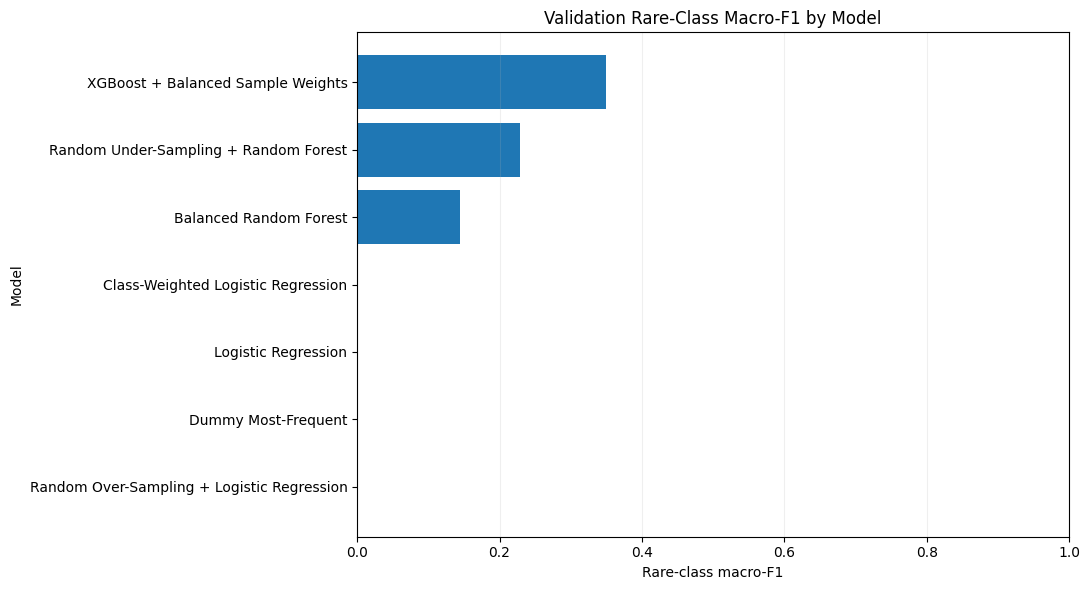

In [71]:
# 20. Validation Figure 10 — Rare-class performance ranking

rare_model_plot_df = validation_results_df.sort_values("rare_macro_f1", ascending=True)

figure, axis = plt.subplots(figsize=(11, 6))
axis.barh(rare_model_plot_df["model"], rare_model_plot_df["rare_macro_f1"])
axis.set_title("Validation Rare-Class Macro-F1 by Model")
axis.set_xlabel("Rare-class macro-F1")
axis.set_ylabel("Model")
axis.set_xlim(0, 1)
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "10_validation_rare_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()


### Validation false-alarm trade-off

The project aim requires improved minority attack detection **without ignoring false alarms**. The following validation view therefore compares each candidate model's rare-class recall with the proportion of genuinely Normal validation rows that it incorrectly labels as an attack. No arbitrary "acceptable" false-alarm threshold is imposed; the trade-off is reported transparently.


In [72]:
# 20A. Validation Figure 10A — Rare-attack recall vs Normal false-alarm burden

tradeoff_df = validation_results_df[
    validation_results_df["model"] != "Dummy Most-Frequent"
].copy()

fig = px.scatter(
    tradeoff_df,
    x="normal_to_attack_false_alarm_rate",
    y="rare_macro_recall",
    size="macro_f1",
    hover_name="model",
    text="model",
    title="Validation Trade-Off: Rare-Class Recall vs Normal-Traffic False Alarms",
    labels={
        "normal_to_attack_false_alarm_rate": "True Normal traffic labelled as attack",
        "rare_macro_recall": "Rare-class macro recall",
        "macro_f1": "Macro-F1",
    },
    template="plotly_white",
)

fig.update_traces(textposition="top center")
fig.update_xaxes(tickformat=".0%")
fig.update_yaxes(tickformat=".0%", range=[0, 1])
fig.update_layout(height=650)
fig.show()

fig.write_html(
    FIGURE_DIRECTORY / "10A_validation_rare_recall_vs_normal_false_alarm.html"
)

false_alarm_comparison_df = validation_results_df[
    [
        "model",
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "rare_macro_recall",
        "rare_macro_f1",
        "normal_false_alarm_count",
        "normal_to_attack_false_alarm_rate",
    ]
].copy()

display(false_alarm_comparison_df.round(4))

false_alarm_comparison_df.to_csv(
    OUTPUT_DIRECTORY / "validation_false_alarm_tradeoff.csv",
    index=False,
)

,model,accuracy,balanced_accuracy,macro_f1,rare_macro_recall,rare_macro_f1,normal_false_alarm_count,normal_to_attack_false_alarm_rate
0,XGBoost + Balanced Sample Weights,0.7547,0.6537,0.5774,0.5761,0.3492,1810,0.1616
1,Random Under-Sampling + Random Forest,0.8009,0.5226,0.5375,0.1713,0.2284,1769,0.1579
2,Balanced Random Forest,0.7013,0.6589,0.4650,0.6771,0.1443,2303,0.2056
3,Class-Weighted Logistic Regression,0.5310,0.2372,0.1921,0.0577,0.0014,1979,0.1767
4,Logistic Regression,0.5422,0.2013,0.1553,0.0000,0.0000,615,0.0549
5,Random Over-Sampling + Logistic Regression,0.5422,0.2013,0.1553,0.0000,0.0000,615,0.0549
6,Dummy Most-Frequent,0.3194,0.1000,0.0484,0.0000,0.0000,0,0.0000


In [73]:
# 21. Freeze model selection before official test evaluation

selection_candidates_df = validation_results_df[
    validation_results_df["model"] != "Dummy Most-Frequent"
].copy()

selection_candidates_df = selection_candidates_df.sort_values(
    by=[
        "macro_f1",
        "rare_macro_f1",
        "balanced_accuracy",
        "normal_to_attack_false_alarm_rate",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

selected_model_name = selection_candidates_df.iloc[0]["model"]
selected_validation_metrics = selection_candidates_df.iloc[0].to_dict()

print("Model-selection rule:")
print("1. Highest validation macro-F1")
print("2. Tie-breaker: highest rare-class macro-F1")
print("3. Tie-breaker: highest balanced accuracy")
print("4. Final tie-breaker: lower Normal-to-attack false-alarm rate")
print()
print(f"Selected model: {selected_model_name}")

selection_summary = (
    f"**Selected model:** {selected_model_name}\n\n"
    f"- Validation macro-F1: "
    f"{selected_validation_metrics['macro_f1']:.4f}\n"
    f"- Validation balanced accuracy: "
    f"{selected_validation_metrics['balanced_accuracy']:.4f}\n"
    f"- Validation rare-class macro-F1: "
    f"{selected_validation_metrics['rare_macro_f1']:.4f}\n"
    f"- Validation rare-class recall: "
    f"{selected_validation_metrics['rare_macro_recall']:.4f}\n"
    f"- Validation Normal-to-attack false-alarm rate: "
    f"{selected_validation_metrics['normal_to_attack_false_alarm_rate']:.4f}\n"
)

display(Markdown(selection_summary))

Model-selection rule:
1. Highest validation macro-F1
2. Tie-breaker: highest rare-class macro-F1
3. Tie-breaker: highest balanced accuracy
4. Final tie-breaker: lower Normal-to-attack false-alarm rate

Selected model: XGBoost + Balanced Sample Weights


**Selected model:** XGBoost + Balanced Sample Weights

- Validation macro-F1: 0.5774
- Validation balanced accuracy: 0.6537
- Validation rare-class macro-F1: 0.3492
- Validation rare-class recall: 0.5761
- Validation Normal-to-attack false-alarm rate: 0.1616



## 22. Final model refit and one-time official test evaluation

The model architecture and selection rule are now frozen. The selected pipeline is refitted using the **entire official training set**, after which it is evaluated on the untouched official test set.

This separation avoids selecting a model based on test performance.


In [74]:
# 22. Refit selected pipeline on ALL official training data

selected_model_template = candidate_models[selected_model_name]

final_model = fit_candidate_model(
    model_name=selected_model_name,
    model_object=selected_model_template,
    train_features=official_train_features_df,
    train_target=official_train_target,
)

print(f"Final model fitted on {len(official_train_features_df):,} official training rows.")

Final model fitted on 175,341 official training rows.


In [75]:
# 23. Official test evaluation

final_test_predictions = final_model.predict(official_test_features_df)
final_test_probabilities = safe_predict_proba(final_model, official_test_features_df)

final_test_metrics = calculate_multiclass_metrics(
    y_true=official_test_target,
    y_predicted=final_test_predictions,
    predicted_probabilities=final_test_probabilities,
)

final_test_metrics_df = pd.DataFrame(
    [{"model": selected_model_name, **final_test_metrics}]
)

display(final_test_metrics_df.round(4))
final_test_metrics_df.to_csv(
    OUTPUT_DIRECTORY / "final_test_metrics.csv",
    index=False,
)

test_classification_report_dict = classification_report(
    official_test_target,
    final_test_predictions,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

test_classification_report_df = (
    pd.DataFrame(test_classification_report_dict)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

display(test_classification_report_df.round(4))
test_classification_report_df.to_csv(
    OUTPUT_DIRECTORY / "final_test_classification_report.csv",
    index=False,
)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,mcc,rare_macro_precision,rare_macro_recall,rare_macro_f1,normal_support,normal_correct_count,normal_false_alarm_count,normal_to_attack_false_alarm_rate,normal_recall,macro_ovr_roc_auc,macro_average_precision
0,XGBoost + Balanced Sample Weights,0.689,0.6231,0.5138,0.6231,0.5027,0.7417,0.6267,0.2144,0.5737,0.2721,37000,22979,14021,0.3789,0.6211,0.9603,0.561


,class_or_average,precision,recall,f1-score,support
0,Analysis,0.0178,0.0768,0.0289,677.000
1,Backdoor,0.0529,0.5901,0.0971,583.000
2,DoS,0.3268,0.1961,0.2451,4089.000
3,Exploits,0.8268,0.5985,0.6944,11132.000
4,Fuzzers,0.2789,0.7092,0.4004,6062.000
5,Generic,0.9988,0.9676,0.9830,18871.000
6,Normal,0.9813,0.6211,0.7607,37000.000
7,Reconnaissance,0.8671,0.8438,0.8553,3496.000
8,Shellcode,0.1909,0.9233,0.3164,378.000
9,Worms,0.5962,0.7045,0.6458,44.000


In [76]:
# 24. Derive detailed per-class false-alarm metrics

final_confusion_matrix = confusion_matrix(
    official_test_target,
    final_test_predictions,
    labels=np.arange(len(class_names)),
)

per_class_rows = []

for class_index, class_name in enumerate(class_names):
    true_positive = final_confusion_matrix[class_index, class_index]
    false_negative = final_confusion_matrix[class_index, :].sum() - true_positive
    false_positive = final_confusion_matrix[:, class_index].sum() - true_positive
    true_negative = final_confusion_matrix.sum() - true_positive - false_negative - false_positive

    precision_value = (
        true_positive / (true_positive + false_positive)
        if (true_positive + false_positive) > 0
        else 0.0
    )
    recall_value = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0.0
    )
    f1_value = (
        2 * precision_value * recall_value / (precision_value + recall_value)
        if (precision_value + recall_value) > 0
        else 0.0
    )
    false_positive_rate = (
        false_positive / (false_positive + true_negative)
        if (false_positive + true_negative) > 0
        else 0.0
    )

    per_class_rows.append(
        {
            "attack_class": class_name,
            "support": int((official_test_target == class_index).sum()),
            "predicted_count": int((final_test_predictions == class_index).sum()),
            "precision": precision_value,
            "recall": recall_value,
            "f1": f1_value,
            "false_positive_rate": false_positive_rate,
            "is_low_frequency": class_name in rare_class_names,
        }
    )

per_class_metrics_df = pd.DataFrame(per_class_rows)
display(per_class_metrics_df.round(4))

per_class_metrics_df.to_csv(
    OUTPUT_DIRECTORY / "final_test_per_class_metrics.csv",
    index=False,
)

,attack_class,support,predicted_count,precision,recall,f1,false_positive_rate,is_low_frequency
0,Analysis,677,2920,0.0178,0.0768,0.0289,0.0351,True
1,Backdoor,583,6505,0.0529,0.5901,0.0971,0.0754,True
2,DoS,4089,2454,0.3268,0.1961,0.2451,0.0211,False
3,Exploits,11132,8059,0.8268,0.5985,0.6944,0.0196,False
4,Fuzzers,6062,15413,0.2789,0.7092,0.4004,0.1457,False
5,Generic,18871,18282,0.9988,0.9676,0.9830,0.0003,False
6,Normal,37000,23417,0.9813,0.6211,0.7607,0.0097,False
7,Reconnaissance,3496,3402,0.8671,0.8438,0.8553,0.0057,False
8,Shellcode,378,1828,0.1909,0.9233,0.3164,0.0180,True
9,Worms,44,52,0.5962,0.7045,0.6458,0.0003,True



## 25. Duplicate-overlap and generalisation sensitivity analysis

The official test metrics remain the primary benchmark result because they use the supplied predefined split. To assess whether exact repeated signatures materially affect the interpretation, the selected model is additionally evaluated on:

1. the complete official test set;
2. the test set after removing any row whose predictor-plus-target signature also occurs in training;
3. a stricter test subset containing only the first occurrence of each test signature and excluding all train/test signature overlap.

A second sensitivity model can also be refitted on one copy of each unique training predictor-plus-target signature and evaluated on the strict test subset. This additional model is **not** used for model selection; it is a robustness check only.


In [77]:
# 25. Generalisation sensitivity analysis for duplicate and cross-split overlap

def evaluate_prediction_subset(
    subset_name: str,
    row_mask: np.ndarray,
    predictions: np.ndarray,
    probabilities: np.ndarray | None,
) -> dict[str, float]:
    """Evaluate already-frozen predictions on a specified test subset."""
    subset_target = official_test_target[row_mask]
    subset_predictions = predictions[row_mask]

    subset_probabilities = None
    if probabilities is not None:
        subset_probabilities = probabilities[row_mask]

    subset_metrics = calculate_multiclass_metrics(
        y_true=subset_target,
        y_predicted=subset_predictions,
        predicted_probabilities=subset_probabilities,
    )

    return {
        "evaluation": subset_name,
        "rows": int(row_mask.sum()),
        **subset_metrics,
    }


sensitivity_rows = []

official_test_mask = np.ones(
    len(official_test_target),
    dtype=bool,
)

sensitivity_rows.append(
    evaluate_prediction_subset(
        subset_name="Official test",
        row_mask=official_test_mask,
        predictions=final_test_predictions,
        probabilities=final_test_probabilities,
    )
)

if overlap_free_test_mask.sum() > 0:
    sensitivity_rows.append(
        evaluate_prediction_subset(
            subset_name="Test excluding train/test exact signature overlap",
            row_mask=overlap_free_test_mask,
            predictions=final_test_predictions,
            probabilities=final_test_probabilities,
        )
    )

if strict_unique_overlap_free_test_mask.sum() > 0:
    sensitivity_rows.append(
        evaluate_prediction_subset(
            subset_name="Unique and overlap-free test",
            row_mask=strict_unique_overlap_free_test_mask,
            predictions=final_test_predictions,
            probabilities=final_test_probabilities,
        )
    )

generalisation_sensitivity_df = pd.DataFrame(sensitivity_rows)

display(
    generalisation_sensitivity_df[
        [
            "evaluation",
            "rows",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "rare_macro_recall",
            "rare_macro_f1",
            "normal_to_attack_false_alarm_rate",
            "macro_ovr_roc_auc",
            "macro_average_precision",
        ]
    ].round(4)
)

generalisation_sensitivity_df.to_csv(
    OUTPUT_DIRECTORY / "generalisation_overlap_sensitivity.csv",
    index=False,
)

sensitivity_long_df = generalisation_sensitivity_df.melt(
    id_vars=["evaluation", "rows"],
    value_vars=[
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "rare_macro_recall",
        "rare_macro_f1",
    ],
    var_name="metric",
    value_name="score",
)

fig = px.bar(
    sensitivity_long_df,
    x="evaluation",
    y="score",
    color="metric",
    barmode="group",
    title="Generalisation Sensitivity After Removing Exact Signature Overlap",
    labels={
        "evaluation": "Evaluation subset",
        "score": "Score",
        "metric": "Metric",
    },
    template="plotly_white",
)
fig.update_xaxes(tickangle=20)
fig.update_yaxes(range=[0, 1])
fig.update_layout(height=650)
fig.show()

fig.write_html(
    FIGURE_DIRECTORY / "11_generalisation_overlap_sensitivity.html"
)

,evaluation,rows,accuracy,balanced_accuracy,macro_f1,rare_macro_recall,rare_macro_f1,normal_to_attack_false_alarm_rate,macro_ovr_roc_auc,macro_average_precision
0,Official test,82332,0.6890,0.6231,0.5027,0.5737,0.2721,0.3789,0.9603,0.5610
1,Test excluding train/test exact signature overlap,63736,0.6780,0.6377,0.5053,0.5873,0.2672,0.3730,0.9610,0.5565
2,Unique and overlap-free test,48400,0.6691,0.6254,0.5031,0.5780,0.2890,0.3639,0.9647,0.5671


In [78]:
# 26. Optional deduplicated-training sensitivity model

deduplicated_training_sensitivity_df = pd.DataFrame()

if RUN_DEDUPLICATED_SENSITIVITY:
    deduplicated_train_features_df = (
        official_train_features_df.loc[train_unique_signature_mask]
        .reset_index(drop=True)
    )

    deduplicated_train_target = official_train_target[
        train_unique_signature_mask
    ]

    print(
        f"Deduplicated sensitivity training rows: "
        f"{len(deduplicated_train_features_df):,} "
        f"of {len(official_train_features_df):,}"
    )

    sensitivity_model = fit_candidate_model(
        model_name=selected_model_name,
        model_object=selected_model_template,
        train_features=deduplicated_train_features_df,
        train_target=deduplicated_train_target,
    )

    strict_test_features_df = official_test_features_df.loc[
        strict_unique_overlap_free_test_mask
    ]

    strict_test_target = official_test_target[
        strict_unique_overlap_free_test_mask
    ]

    deduplicated_sensitivity_predictions = sensitivity_model.predict(
        strict_test_features_df
    )

    deduplicated_sensitivity_probabilities = safe_predict_proba(
        sensitivity_model,
        strict_test_features_df,
    )

    deduplicated_sensitivity_metrics = calculate_multiclass_metrics(
        y_true=strict_test_target,
        y_predicted=deduplicated_sensitivity_predictions,
        predicted_probabilities=deduplicated_sensitivity_probabilities,
    )

    primary_strict_row = generalisation_sensitivity_df.loc[
        generalisation_sensitivity_df["evaluation"]
        == "Unique and overlap-free test"
    ].iloc[0]

    comparison_rows = [
        {
            "model_fit": "Primary model trained on complete official training split",
            "evaluation": "Unique and overlap-free test",
            "rows": int(len(strict_test_target)),
            **{
                metric_name: primary_strict_row[metric_name]
                for metric_name in [
                    "accuracy",
                    "balanced_accuracy",
                    "macro_f1",
                    "rare_macro_recall",
                    "rare_macro_f1",
                    "normal_to_attack_false_alarm_rate",
                    "macro_ovr_roc_auc",
                    "macro_average_precision",
                ]
            },
        },
        {
            "model_fit": "Sensitivity model trained on unique training signatures",
            "evaluation": "Unique and overlap-free test",
            "rows": int(len(strict_test_target)),
            **deduplicated_sensitivity_metrics,
        },
    ]

    deduplicated_training_sensitivity_df = pd.DataFrame(
        comparison_rows
    )

    display(
        deduplicated_training_sensitivity_df[
            [
                "model_fit",
                "rows",
                "accuracy",
                "balanced_accuracy",
                "macro_f1",
                "rare_macro_recall",
                "rare_macro_f1",
                "normal_to_attack_false_alarm_rate",
                "macro_ovr_roc_auc",
                "macro_average_precision",
            ]
        ].round(4)
    )

    deduplicated_training_sensitivity_df.to_csv(
        OUTPUT_DIRECTORY / "deduplicated_training_sensitivity.csv",
        index=False,
    )
else:
    print("Deduplicated-training sensitivity analysis is disabled.")

Deduplicated sensitivity training rows: 96,822 of 175,341


,model_fit,rows,accuracy,balanced_accuracy,macro_f1,rare_macro_recall,rare_macro_f1,normal_to_attack_false_alarm_rate,macro_ovr_roc_auc,macro_average_precision
0,Primary model trained on complete official tra...,48400,0.6691,0.6254,0.5031,0.5780,0.2890,0.3639,0.9647,0.5671
1,Sensitivity model trained on unique training s...,48400,0.6648,0.6520,0.5108,0.6042,0.2921,0.3722,0.9641,0.5561


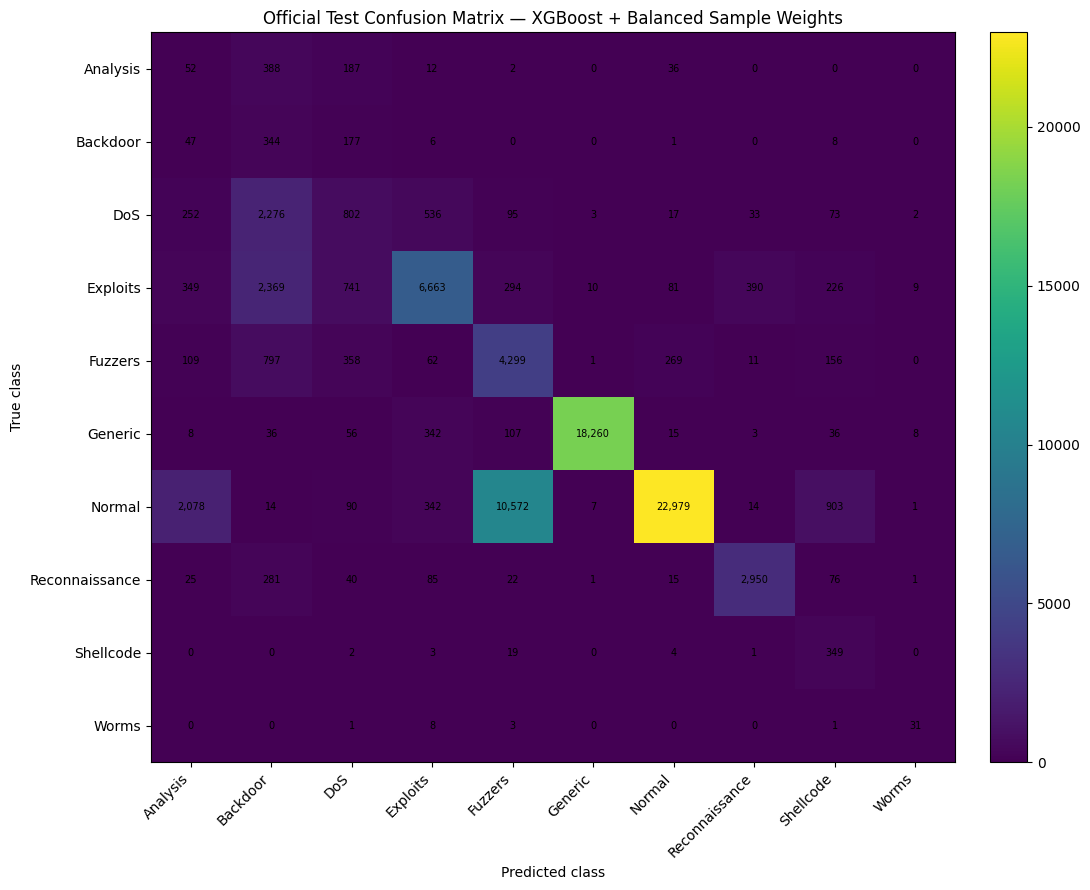

In [79]:
# 25. Test Figure 11 — Raw confusion matrix

figure, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(final_confusion_matrix, aspect="auto")
axis.set_xticks(np.arange(len(class_names)))
axis.set_yticks(np.arange(len(class_names)))
axis.set_xticklabels(class_names, rotation=45, ha="right")
axis.set_yticklabels(class_names)
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
axis.set_title(f"Official Test Confusion Matrix — {selected_model_name}")

for row_index in range(final_confusion_matrix.shape[0]):
    for column_index in range(final_confusion_matrix.shape[1]):
        axis.text(
            column_index,
            row_index,
            f"{final_confusion_matrix[row_index, column_index]:,}",
            ha="center",
            va="center",
            fontsize=7,
        )

figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "11_test_confusion_matrix_counts.png", dpi=180, bbox_inches="tight")
plt.show()

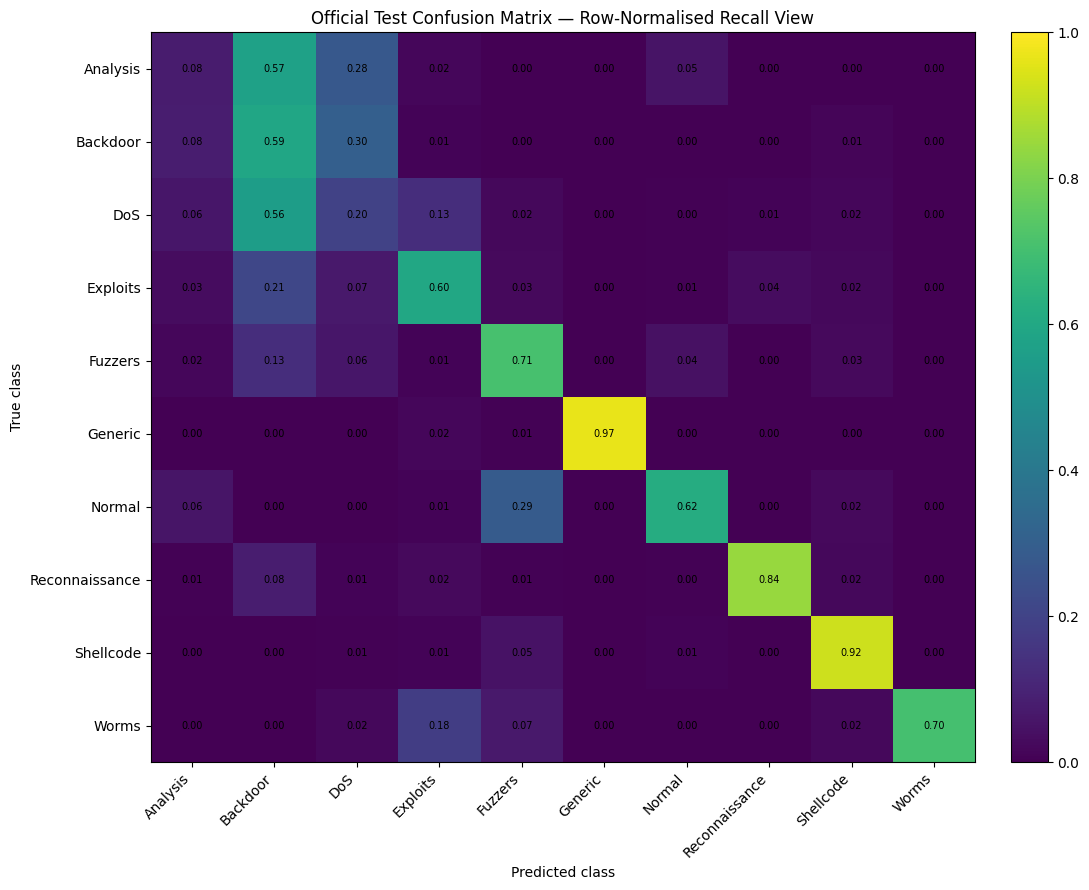

In [80]:
# 26. Test Figure 12 — Row-normalised confusion matrix

row_totals = final_confusion_matrix.sum(axis=1, keepdims=True)
normalized_confusion_matrix = np.divide(
    final_confusion_matrix,
    row_totals,
    out=np.zeros_like(final_confusion_matrix, dtype=float),
    where=row_totals != 0,
)

figure, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(normalized_confusion_matrix, aspect="auto", vmin=0, vmax=1)
axis.set_xticks(np.arange(len(class_names)))
axis.set_yticks(np.arange(len(class_names)))
axis.set_xticklabels(class_names, rotation=45, ha="right")
axis.set_yticklabels(class_names)
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
axis.set_title("Official Test Confusion Matrix — Row-Normalised Recall View")

for row_index in range(normalized_confusion_matrix.shape[0]):
    for column_index in range(normalized_confusion_matrix.shape[1]):
        axis.text(
            column_index,
            row_index,
            f"{normalized_confusion_matrix[row_index, column_index]:.2f}",
            ha="center",
            va="center",
            fontsize=7,
        )

figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "12_test_confusion_matrix_normalized.png", dpi=180, bbox_inches="tight")
plt.show()

In [81]:
# 27. Test Figure 13 — Per-class precision, recall, and F1

per_class_long_df = per_class_metrics_df.melt(
    id_vars=["attack_class", "is_low_frequency"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

fig = px.bar(
    per_class_long_df,
    x="attack_class",
    y="score",
    color="metric",
    barmode="group",
    pattern_shape="is_low_frequency",
    title="Official Test Per-Class Precision, Recall and F1",
    labels={
        "attack_class": "Class",
        "score": "Score",
        "metric": "Metric",
        "is_low_frequency": "Low-frequency class",
    },
    template="plotly_white",
)
fig.update_xaxes(tickangle=35)
fig.update_layout(height=600, yaxis_range=[0, 1])
fig.show()
fig.write_html(FIGURE_DIRECTORY / "13_test_per_class_metrics.html")

In [82]:
# 28. Test Figure 14 — Support vs F1 (rare-class stability context)

fig = px.scatter(
    per_class_metrics_df,
    x="support",
    y="f1",
    size="support",
    hover_name="attack_class",
    symbol="is_low_frequency",
    log_x=True,
    title="Official Test Support vs F1",
    labels={
        "support": "Test support (log scale)",
        "f1": "F1 score",
        "is_low_frequency": "Low-frequency class",
    },
    template="plotly_white",
)
fig.update_yaxes(range=[0, 1])
fig.show()
fig.write_html(FIGURE_DIRECTORY / "14_test_support_vs_f1.html")

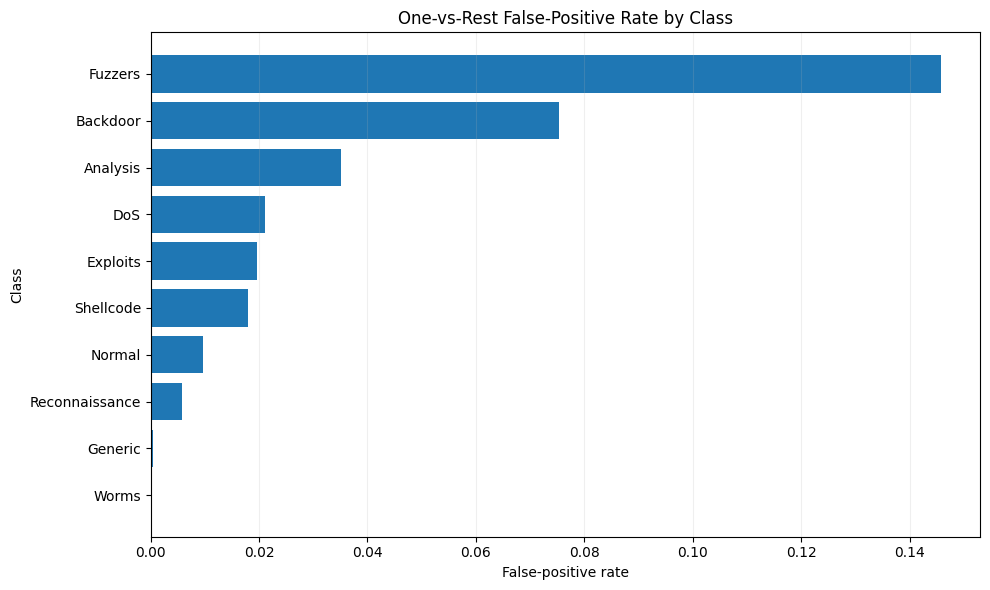

In [83]:
# 29. Test Figure 15 — False-positive rate by class

false_alarm_plot_df = per_class_metrics_df.sort_values("false_positive_rate", ascending=True)

figure, axis = plt.subplots(figsize=(10, 6))
axis.barh(false_alarm_plot_df["attack_class"], false_alarm_plot_df["false_positive_rate"])
axis.set_title("One-vs-Rest False-Positive Rate by Class")
axis.set_xlabel("False-positive rate")
axis.set_ylabel("Class")
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "15_test_false_positive_rate_by_class.png", dpi=180, bbox_inches="tight")
plt.show()

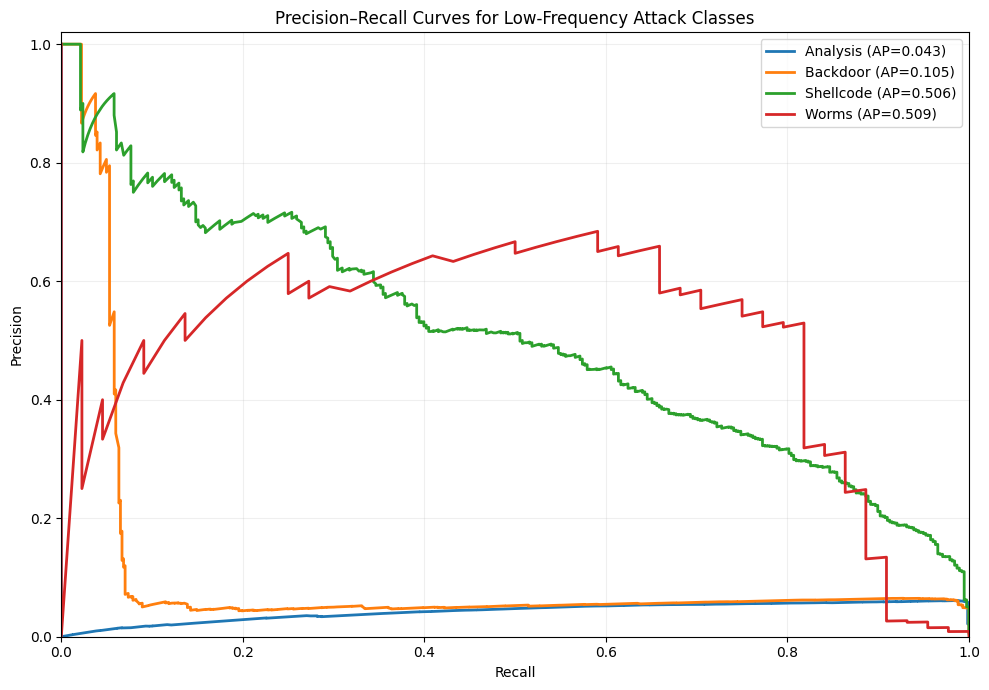

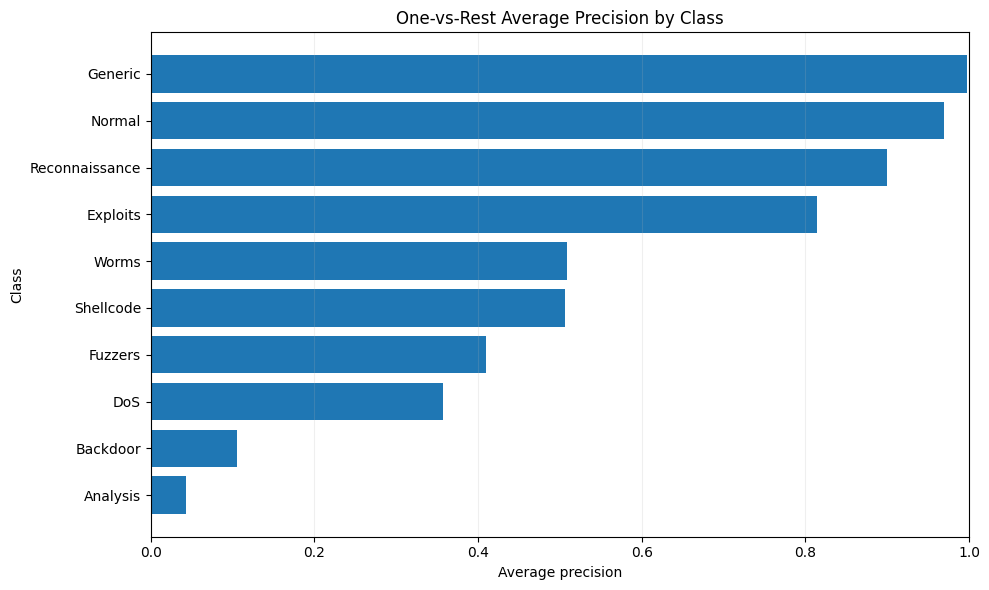

In [84]:
# 30. Test Figures 16–17 — Precision–Recall analysis

if final_test_probabilities is None:
    print("Selected model does not provide class probabilities; PR analysis skipped.")
else:
    test_target_binary = label_binarize(
        official_test_target,
        classes=np.arange(len(class_names)),
    )

    average_precision_rows = []

    # Rare-class PR curves on one interpretable figure.
    figure, axis = plt.subplots(figsize=(10, 7))

    for class_index, class_name in enumerate(class_names):
        precision_values, recall_values, _ = precision_recall_curve(
            test_target_binary[:, class_index],
            final_test_probabilities[:, class_index],
        )

        ap_value = average_precision_score(
            test_target_binary[:, class_index],
            final_test_probabilities[:, class_index],
        )

        average_precision_rows.append(
            {
                "attack_class": class_name,
                "average_precision": ap_value,
                "is_low_frequency": class_name in rare_class_names,
            }
        )

        if class_name in rare_class_names:
            axis.plot(
                recall_values,
                precision_values,
                linewidth=2,
                label=f"{class_name} (AP={ap_value:.3f})",
            )

    axis.set_title("Precision–Recall Curves for Low-Frequency Attack Classes")
    axis.set_xlabel("Recall")
    axis.set_ylabel("Precision")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.02)
    axis.grid(alpha=0.2)
    if rare_class_names:
        axis.legend()
    figure.tight_layout()
    figure.savefig(FIGURE_DIRECTORY / "16_rare_class_precision_recall_curves.png", dpi=180, bbox_inches="tight")
    plt.show()

    average_precision_df = pd.DataFrame(average_precision_rows).sort_values(
        "average_precision",
        ascending=True,
    )

    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh(average_precision_df["attack_class"], average_precision_df["average_precision"])
    axis.set_title("One-vs-Rest Average Precision by Class")
    axis.set_xlabel("Average precision")
    axis.set_ylabel("Class")
    axis.set_xlim(0, 1)
    axis.grid(axis="x", alpha=0.2)
    figure.tight_layout()
    figure.savefig(FIGURE_DIRECTORY / "17_average_precision_by_class.png", dpi=180, bbox_inches="tight")
    plt.show()

    average_precision_df.to_csv(
        OUTPUT_DIRECTORY / "final_test_average_precision_by_class.csv",
        index=False,
    )

In [85]:
# 31. Test Figure 18 — Actual vs predicted class counts

actual_counts = pd.Series(official_test_target).value_counts().sort_index()
predicted_counts = pd.Series(final_test_predictions).value_counts().sort_index()

actual_vs_predicted_df = pd.DataFrame(
    {
        "attack_class": class_names,
        "Actual": [actual_counts.get(index, 0) for index in range(len(class_names))],
        "Predicted": [predicted_counts.get(index, 0) for index in range(len(class_names))],
    }
)

actual_vs_predicted_long_df = actual_vs_predicted_df.melt(
    id_vars="attack_class",
    var_name="series",
    value_name="count",
)

fig = px.bar(
    actual_vs_predicted_long_df,
    x="attack_class",
    y="count",
    color="series",
    barmode="group",
    title="Official Test Actual vs Predicted Class Counts",
    labels={"attack_class": "Class", "count": "Records", "series": "Series"},
    template="plotly_white",
)
fig.update_xaxes(tickangle=35)
fig.show()
fig.write_html(FIGURE_DIRECTORY / "18_actual_vs_predicted_counts.html")

,predicted_class,count,percentage_of_true_normal
0,Normal,22979,62.105
1,Fuzzers,10572,28.573
2,Analysis,2078,5.616
3,Shellcode,903,2.441
4,Exploits,342,0.924
5,DoS,90,0.243
6,Reconnaissance,14,0.038
7,Backdoor,14,0.038
8,Generic,7,0.019
9,Worms,1,0.003


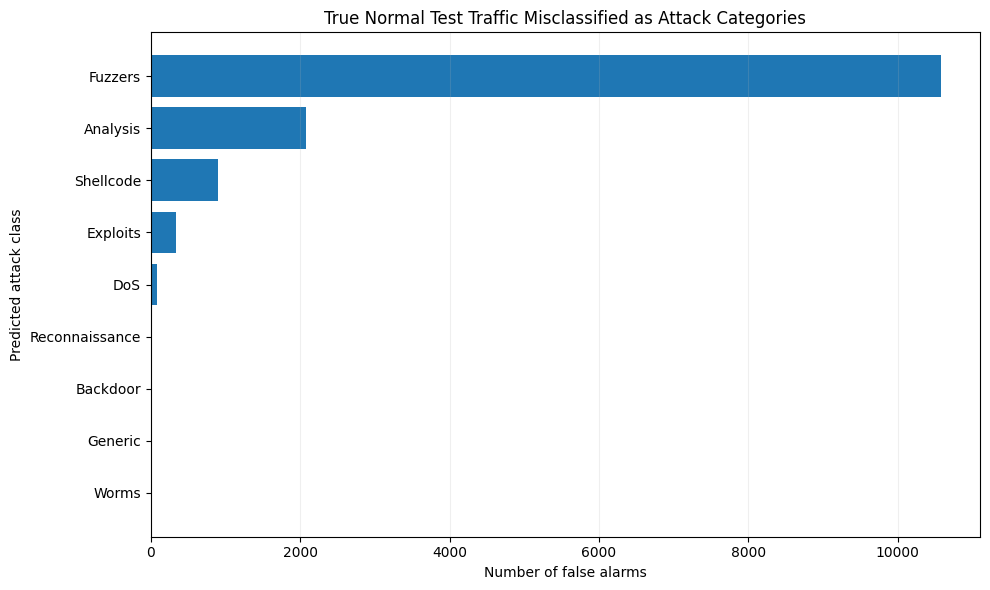

In [86]:
# 31A. Final selected-model Normal false-alarm breakdown

if "Normal" in class_name_to_index:
    normal_index = class_name_to_index["Normal"]
    normal_test_mask = official_test_target == normal_index

    normal_prediction_counts = (
        pd.Series(
            target_encoder.inverse_transform(
                final_test_predictions[normal_test_mask]
            )
        )
        .value_counts()
        .rename_axis("predicted_class")
        .reset_index(name="count")
    )

    normal_prediction_counts["percentage_of_true_normal"] = (
        normal_prediction_counts["count"]
        / normal_test_mask.sum()
        * 100
    )

    display(normal_prediction_counts.round(3))

    normal_prediction_counts.to_csv(
        OUTPUT_DIRECTORY / "final_test_normal_false_alarm_breakdown.csv",
        index=False,
    )

    normal_attack_predictions_df = normal_prediction_counts.loc[
        normal_prediction_counts["predicted_class"] != "Normal"
    ].sort_values("count", ascending=True)

    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh(
        normal_attack_predictions_df["predicted_class"],
        normal_attack_predictions_df["count"],
    )
    axis.set_title(
        "True Normal Test Traffic Misclassified as Attack Categories"
    )
    axis.set_xlabel("Number of false alarms")
    axis.set_ylabel("Predicted attack class")
    axis.grid(axis="x", alpha=0.2)
    figure.tight_layout()
    figure.savefig(
        FIGURE_DIRECTORY / "18A_normal_false_alarm_breakdown.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

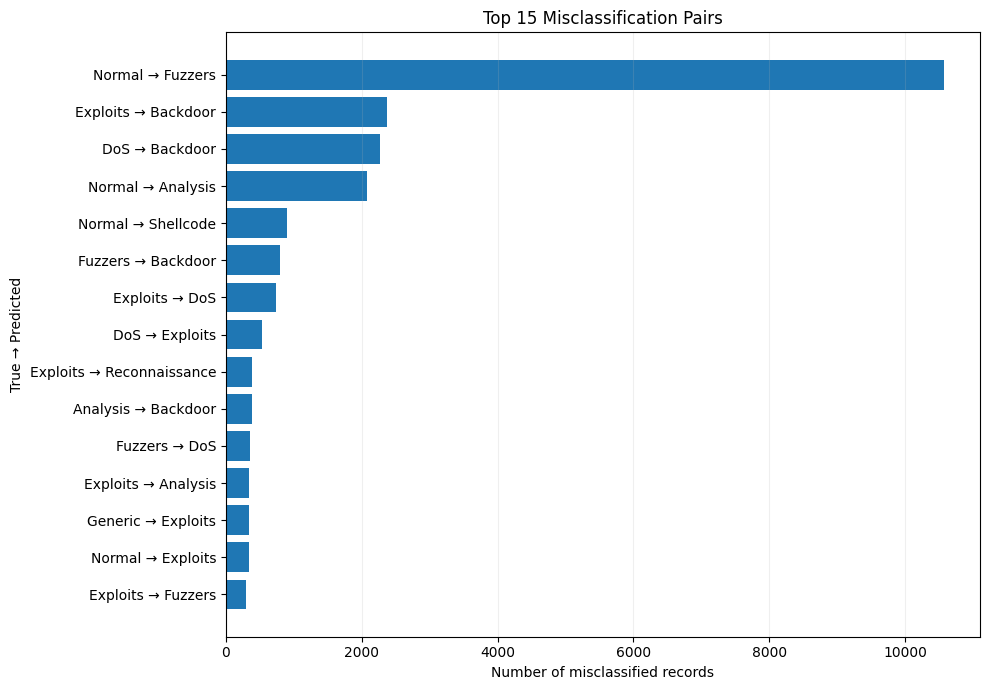

In [87]:
# 32. Test Figure 19 — Most frequent confusion pairs

confusion_pair_rows = []

for true_index, true_name in enumerate(class_names):
    for predicted_index, predicted_name in enumerate(class_names):
        if true_index == predicted_index:
            continue

        confusion_pair_rows.append(
            {
                "true_class": true_name,
                "predicted_class": predicted_name,
                "count": int(final_confusion_matrix[true_index, predicted_index]),
            }
        )

confusion_pairs_df = (
    pd.DataFrame(confusion_pair_rows)
    .sort_values("count", ascending=False)
    .head(15)
)

confusion_pairs_df["pair"] = (
    confusion_pairs_df["true_class"] + " → " + confusion_pairs_df["predicted_class"]
)

figure, axis = plt.subplots(figsize=(10, 7))
axis.barh(confusion_pairs_df["pair"][::-1], confusion_pairs_df["count"][::-1])
axis.set_title("Top 15 Misclassification Pairs")
axis.set_xlabel("Number of misclassified records")
axis.set_ylabel("True → Predicted")
axis.grid(axis="x", alpha=0.2)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / "19_top_confusion_pairs.png", dpi=180, bbox_inches="tight")
plt.show()

confusion_pairs_df.to_csv(
    OUTPUT_DIRECTORY / "final_test_top_confusion_pairs.csv",
    index=False,
)

In [88]:
# 33. Test Figure 20 — Prediction-confidence distribution

if final_test_probabilities is None:
    print("Selected model does not expose probabilities; confidence plot skipped.")
else:
    maximum_confidence = final_test_probabilities.max(axis=1)
    correct_prediction_mask = final_test_predictions == official_test_target

    confidence_df = pd.DataFrame(
        {
            "maximum_probability": maximum_confidence,
            "prediction_status": np.where(correct_prediction_mask, "Correct", "Incorrect"),
        }
    )

    fig = px.histogram(
        confidence_df,
        x="maximum_probability",
        color="prediction_status",
        nbins=40,
        barmode="overlay",
        title="Prediction Confidence for Correct vs Incorrect Test Predictions",
        labels={
            "maximum_probability": "Maximum predicted class probability",
            "prediction_status": "Prediction status",
        },
        template="plotly_white",
    )
    fig.show()
    fig.write_html(FIGURE_DIRECTORY / "20_prediction_confidence.html")

In [89]:
# 34. Feature-importance extraction

def get_pipeline_steps(fitted_pipeline):
    if not hasattr(fitted_pipeline, "named_steps"):
        return None, None

    preprocessor = fitted_pipeline.named_steps.get("preprocessor")
    classifier = fitted_pipeline.named_steps.get("classifier")
    return preprocessor, classifier


def extract_builtin_feature_importance(fitted_pipeline) -> pd.DataFrame | None:
    preprocessor, classifier = get_pipeline_steps(fitted_pipeline)

    if preprocessor is None or classifier is None:
        return None

    try:
        feature_names = preprocessor.get_feature_names_out()
    except Exception:
        return None

    if hasattr(classifier, "feature_importances_"):
        importance_values = np.asarray(classifier.feature_importances_)
    elif hasattr(classifier, "coef_"):
        coefficients = np.asarray(classifier.coef_)
        if coefficients.ndim == 1:
            importance_values = np.abs(coefficients)
        else:
            importance_values = np.mean(np.abs(coefficients), axis=0)
    else:
        return None

    if len(feature_names) != len(importance_values):
        return None

    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importance_values,
        }
    ).sort_values("importance", ascending=False)

    return importance_df.reset_index(drop=True)


feature_importance_df = extract_builtin_feature_importance(final_model)

if feature_importance_df is None:
    print("No built-in feature importance available for the selected model.")
else:
    display(feature_importance_df.head(MAX_FEATURE_IMPORTANCE_ROWS))
    feature_importance_df.to_csv(
        OUTPUT_DIRECTORY / "final_model_feature_importance.csv",
        index=False,
    )

,feature,importance
0,categorical__service_dns,0.237234
1,categorical__service_http,0.114156
2,numeric__is_sm_ips_ports,0.060759
3,categorical__proto_arp,0.059805
4,categorical__proto_udp,0.053714
5,categorical__proto_ospf,0.025842
6,categorical__service_-,0.025284
7,categorical__service_ftp-data,0.016815
8,categorical__state_FIN,0.015972
9,numeric__ct_flw_http_mthd,0.013755


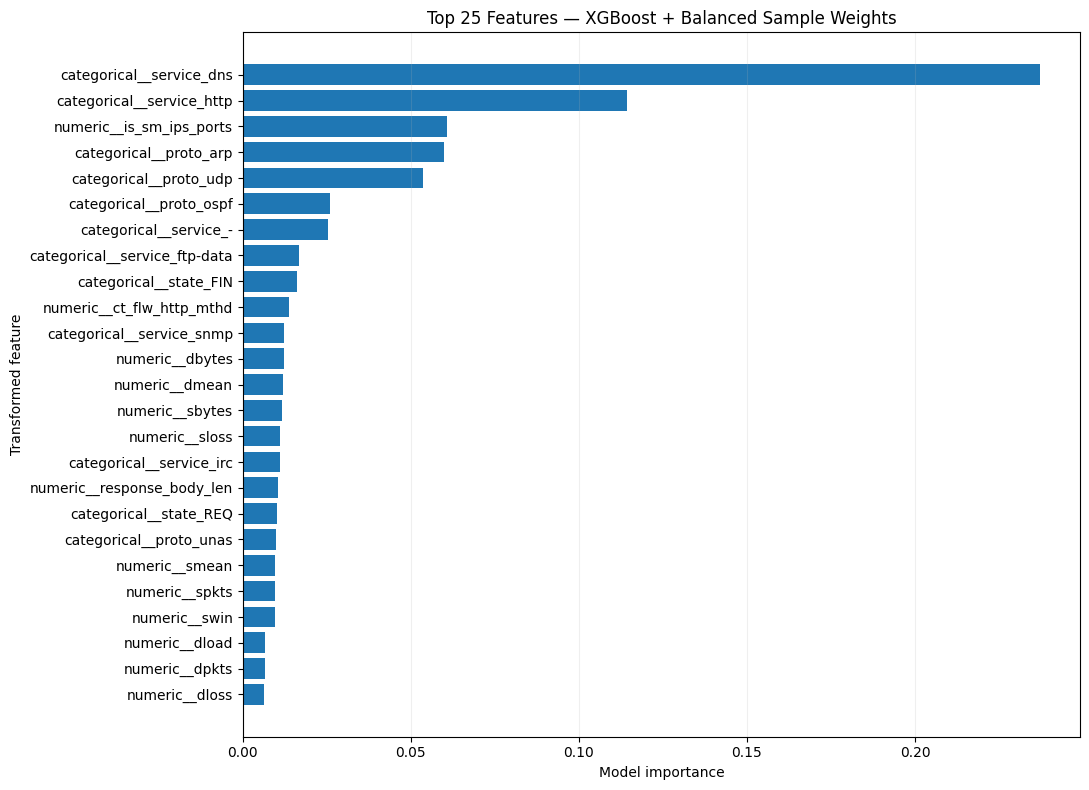

In [90]:
# 35. Test Figure 21 — Top model features

if feature_importance_df is None:
    print("Feature-importance chart skipped.")
else:
    top_feature_importance_df = (
        feature_importance_df.head(MAX_FEATURE_IMPORTANCE_ROWS)
        .sort_values("importance", ascending=True)
    )

    figure, axis = plt.subplots(figsize=(11, 8))
    axis.barh(
        top_feature_importance_df["feature"],
        top_feature_importance_df["importance"],
    )
    axis.set_title(f"Top {MAX_FEATURE_IMPORTANCE_ROWS} Features — {selected_model_name}")
    axis.set_xlabel("Model importance")
    axis.set_ylabel("Transformed feature")
    axis.grid(axis="x", alpha=0.2)
    figure.tight_layout()
    figure.savefig(FIGURE_DIRECTORY / "21_final_model_feature_importance.png", dpi=180, bbox_inches="tight")
    plt.show()

In [91]:
# 36. Rare-class focused result table for the report

rare_class_test_results_df = (
    per_class_metrics_df.loc[per_class_metrics_df["is_low_frequency"]]
    .sort_values(["f1", "recall"], ascending=False)
    .reset_index(drop=True)
)

print("Low-frequency attack classes defined from official training prevalence:")
display(rare_class_test_results_df.round(4))

rare_class_test_results_df.to_csv(
    OUTPUT_DIRECTORY / "rare_class_final_test_results.csv",
    index=False,
)

Low-frequency attack classes defined from official training prevalence:


,attack_class,support,predicted_count,precision,recall,f1,false_positive_rate,is_low_frequency
0,Worms,44,52,0.5962,0.7045,0.6458,0.0003,True
1,Shellcode,378,1828,0.1909,0.9233,0.3164,0.0180,True
2,Backdoor,583,6505,0.0529,0.5901,0.0971,0.0754,True
3,Analysis,677,2920,0.0178,0.0768,0.0289,0.0351,True


,metric,dummy_baseline,selected_model,absolute_improvement
0,accuracy,0.3194,0.7547,0.4354
1,balanced_accuracy,0.1000,0.6537,0.5537
2,macro_f1,0.0484,0.5774,0.5290
3,rare_macro_f1,0.0000,0.3492,0.3492
4,rare_macro_recall,0.0000,0.5761,0.5761


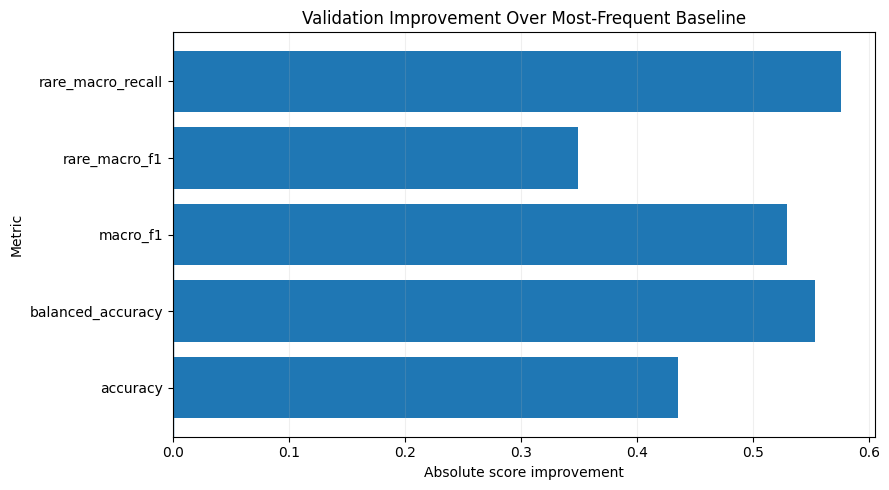

In [92]:
# 37. Optional sensitivity view — performance gain over naïve baseline

dummy_row = validation_results_df.loc[
    validation_results_df["model"] == "Dummy Most-Frequent"
]

selected_row = validation_results_df.loc[
    validation_results_df["model"] == selected_model_name
]

if not dummy_row.empty and not selected_row.empty:
    metric_names = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "rare_macro_f1",
        "rare_macro_recall",
    ]

    improvement_rows = []
    for metric_name in metric_names:
        dummy_value = float(dummy_row.iloc[0][metric_name])
        selected_value = float(selected_row.iloc[0][metric_name])
        improvement_rows.append(
            {
                "metric": metric_name,
                "dummy_baseline": dummy_value,
                "selected_model": selected_value,
                "absolute_improvement": selected_value - dummy_value,
            }
        )

    improvement_df = pd.DataFrame(improvement_rows)
    display(improvement_df.round(4))

    figure, axis = plt.subplots(figsize=(9, 5))
    axis.barh(improvement_df["metric"], improvement_df["absolute_improvement"])
    axis.axvline(0, linewidth=1)
    axis.set_title("Validation Improvement Over Most-Frequent Baseline")
    axis.set_xlabel("Absolute score improvement")
    axis.set_ylabel("Metric")
    axis.grid(axis="x", alpha=0.2)
    figure.tight_layout()
    figure.savefig(FIGURE_DIRECTORY / "22_improvement_over_dummy_baseline.png", dpi=180, bbox_inches="tight")
    plt.show()

In [93]:
# 38. Save prediction-level analytical outputs (no raw feature export)

prediction_output_df = pd.DataFrame(
    {
        "true_class": target_encoder.inverse_transform(official_test_target),
        "predicted_class": target_encoder.inverse_transform(final_test_predictions),
        "is_correct": final_test_predictions == official_test_target,
    }
)

if final_test_probabilities is not None:
    prediction_output_df["maximum_predicted_probability"] = final_test_probabilities.max(axis=1)

prediction_output_df.to_parquet(
    OUTPUT_DIRECTORY / "final_test_predictions.parquet",
    index=False,
)

print(
    "Saved prediction-level output with true/predicted labels only. "
    "Raw network-feature rows are not re-exported."
)

Saved prediction-level output with true/predicted labels only. Raw network-feature rows are not re-exported.


In [94]:
# 39. Save final model and reproducibility manifest

model_output_path = OUTPUT_DIRECTORY / "selected_final_pipeline.joblib"

if SAVE_FINAL_MODEL:
    joblib.dump(
        final_model,
        model_output_path,
    )
    print(f"Saved fitted pipeline: {model_output_path}")


def safe_metric_dictionary(metric_dictionary: dict) -> dict:
    """Convert NumPy values and non-finite values into JSON-safe values."""
    safe_dictionary = {}

    for key, value in metric_dictionary.items():
        if isinstance(value, (np.integer,)):
            safe_dictionary[key] = int(value)
        elif isinstance(value, (np.floating, float)):
            safe_dictionary[key] = (
                float(value)
                if np.isfinite(value)
                else None
            )
        else:
            safe_dictionary[key] = value

    return safe_dictionary


duplicate_audit_manifest = {
    row["audit_measure"]: {
        "count": int(row["count"]),
        "denominator": int(row["denominator"]),
        "percentage": float(row["percentage"]),
    }
    for _, row in duplicate_overlap_audit_df.iterrows()
}

manifest = {
    "project_title": PROJECT_TITLE,
    "research_design": (
        "Secondary-data multiclass machine-learning analytical prototype"
    ),
    "random_seed": RANDOM_SEED,
    "dataset_directory": str(DATASET_DIRECTORY),
    "training_file": str(train_file_path),
    "testing_file": str(test_file_path),
    "target_column": TARGET_COLUMN,
    "excluded_leakage_column": (
        BINARY_LABEL_COLUMN
        if BINARY_LABEL_COLUMN in official_train_df.columns
        else None
    ),
    "rare_class_prevalence_threshold": RARE_CLASS_PREVALENCE_THRESHOLD,
    "rare_classes": rare_class_names,
    "validation_size": VALIDATION_SIZE,
    "selected_model": selected_model_name,
    "selection_rule": [
        "highest validation macro-F1",
        "highest rare-class macro-F1",
        "highest balanced accuracy",
        "lower Normal-to-attack false-alarm rate",
    ],
    "official_train_shape": list(official_train_df.shape),
    "official_test_shape": list(official_test_df.shape),
    "official_test_metrics": safe_metric_dictionary(
        final_test_metrics
    ),
    "duplicate_and_overlap_audit": duplicate_audit_manifest,
    "software": {
        "python": sys.version,
        "platform": platform.platform(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "ethics_scope": {
        "secondary_public_dataset_only": True,
        "human_participants": False,
        "live_traffic_capture": False,
        "system_probing_or_attack": False,
        "organisational_access": False,
        "raw_dataset_republication": False,
    },
    "credibility_controls": {
        "official_test_not_used_for_model_selection": True,
        "resampling_restricted_to_training_pipeline": True,
        "binary_label_removed_from_multiclass_predictors": True,
        "cross_split_exact_overlap_audited": True,
        "overlap_free_test_sensitivity_evaluated": True,
        "deduplicated_training_sensitivity_enabled": RUN_DEDUPLICATED_SENSITIVITY,
        "normal_traffic_false_alarm_comparison": True,
    },
}

manifest_output_path = OUTPUT_DIRECTORY / "run_manifest.json"

with open(
    manifest_output_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        manifest,
        file,
        indent=2,
    )

print(f"Saved reproducibility manifest: {manifest_output_path}")

Saved fitted pipeline: /kaggle/working/unsw_nb15_low_frequency_attack_project/selected_final_pipeline.joblib
Saved reproducibility manifest: /kaggle/working/unsw_nb15_low_frequency_attack_project/run_manifest.json


In [95]:
# 40. Generate report-ready textual summary from actual results

rare_result_lines = []

for row in rare_class_test_results_df.itertuples(index=False):
    rare_result_lines.append(
        f"- **{row.attack_class}**: "
        f"precision={row.precision:.3f}, "
        f"recall={row.recall:.3f}, "
        f"F1={row.f1:.3f}, "
        f"false-positive rate={row.false_positive_rate:.4f}, "
        f"support={row.support:,}"
    )

cross_overlap_row = duplicate_overlap_audit_df.loc[
    duplicate_overlap_audit_df["audit_measure"]
    == "Testing rows with identical predictor-plus-target signature in training"
].iloc[0]

strict_subset_row = generalisation_sensitivity_df.loc[
    generalisation_sensitivity_df["evaluation"]
    == "Unique and overlap-free test"
]

strict_subset_text = "Not available"

if not strict_subset_row.empty:
    strict_record = strict_subset_row.iloc[0]
    strict_subset_text = (
        f"{int(strict_record['rows']):,} rows; "
        f"macro-F1={strict_record['macro_f1']:.4f}; "
        f"rare recall={strict_record['rare_macro_recall']:.4f}; "
        f"rare F1={strict_record['rare_macro_f1']:.4f}; "
        f"Normal false-alarm rate="
        f"{strict_record['normal_to_attack_false_alarm_rate']:.4f}"
    )

report_summary_markdown = f"""
# Analytical Results Summary

## Selected model
**{selected_model_name}**

The model was selected using only the validation split created from the official
training file. Selection prioritised macro-F1, followed by rare-class macro-F1,
balanced accuracy and, as a final tie-breaker, a lower Normal-to-attack
false-alarm rate.

## Official test performance
- Accuracy: **{final_test_metrics['accuracy']:.4f}**
- Balanced accuracy: **{final_test_metrics['balanced_accuracy']:.4f}**
- Macro precision: **{final_test_metrics['macro_precision']:.4f}**
- Macro recall: **{final_test_metrics['macro_recall']:.4f}**
- Macro-F1: **{final_test_metrics['macro_f1']:.4f}**
- Weighted F1: **{final_test_metrics['weighted_f1']:.4f}**
- Rare-class macro precision: **{final_test_metrics['rare_macro_precision']:.4f}**
- Rare-class macro recall: **{final_test_metrics['rare_macro_recall']:.4f}**
- Rare-class macro-F1: **{final_test_metrics['rare_macro_f1']:.4f}**
- Normal-to-attack false-alarm rate: **{final_test_metrics['normal_to_attack_false_alarm_rate']:.4f}**
- Macro one-vs-rest ROC-AUC: **{final_test_metrics['macro_ovr_roc_auc']:.4f}**
- Macro average precision: **{final_test_metrics['macro_average_precision']:.4f}**

## Low-frequency classes
Low-frequency was operationalised as less than
**{RARE_CLASS_PREVALENCE_THRESHOLD:.1%}** of the official training data.

{chr(10).join(rare_result_lines)}

## Duplicate and cross-split overlap credibility check
Testing rows with an identical predictor-plus-target signature already present
in the official training split:
**{int(cross_overlap_row['count']):,} of {int(cross_overlap_row['denominator']):,}
({cross_overlap_row['percentage']:.2f}%)**.

The primary benchmark result is retained for comparability, while a stricter
sensitivity evaluation excludes these exact signatures.

Strict unique and overlap-free test result:
**{strict_subset_text}**.

## Interpretation requirements
The final report should explicitly discuss:

1. why accuracy alone is inadequate under severe multiclass imbalance;
2. which rare classes improved and which remained difficult;
3. the trade-off between rare-class recall and Normal-traffic false alarms;
4. whether imbalance-aware methods improved macro-F1 and balanced accuracy;
5. the effect, if any, of exact duplicate and cross-split overlap;
6. instability for very small classes such as Worms;
7. the high ROC-AUC versus weaker hard-classification precision/F1 for some rare classes;
8. the controlled-benchmark limitations of UNSW-NB15;
9. that this is an academic analytical prototype, not a deployable intrusion-detection system.
"""

display(Markdown(report_summary_markdown))

with open(
    OUTPUT_DIRECTORY / "REPORT_SUMMARY.md",
    "w",
    encoding="utf-8",
) as file:
    file.write(report_summary_markdown)


# Analytical Results Summary

## Selected model
**XGBoost + Balanced Sample Weights**

The model was selected using only the validation split created from the official
training file. Selection prioritised macro-F1, followed by rare-class macro-F1,
balanced accuracy and, as a final tie-breaker, a lower Normal-to-attack
false-alarm rate.

## Official test performance
- Accuracy: **0.6890**
- Balanced accuracy: **0.6231**
- Macro precision: **0.5138**
- Macro recall: **0.6231**
- Macro-F1: **0.5027**
- Weighted F1: **0.7417**
- Rare-class macro precision: **0.2144**
- Rare-class macro recall: **0.5737**
- Rare-class macro-F1: **0.2721**
- Normal-to-attack false-alarm rate: **0.3789**
- Macro one-vs-rest ROC-AUC: **0.9603**
- Macro average precision: **0.5610**

## Low-frequency classes
Low-frequency was operationalised as less than
**2.0%** of the official training data.

- **Worms**: precision=0.596, recall=0.705, F1=0.646, false-positive rate=0.0003, support=44
- **Shellcode**: precision=0.191, recall=0.923, F1=0.316, false-positive rate=0.0180, support=378
- **Backdoor**: precision=0.053, recall=0.590, F1=0.097, false-positive rate=0.0754, support=583
- **Analysis**: precision=0.018, recall=0.077, F1=0.029, false-positive rate=0.0351, support=677

## Duplicate and cross-split overlap credibility check
Testing rows with an identical predictor-plus-target signature already present
in the official training split:
**18,596 of 82,332
(22.59%)**.

The primary benchmark result is retained for comparability, while a stricter
sensitivity evaluation excludes these exact signatures.

Strict unique and overlap-free test result:
**48,400 rows; macro-F1=0.5031; rare recall=0.5780; rare F1=0.2890; Normal false-alarm rate=0.3639**.

## Interpretation requirements
The final report should explicitly discuss:

1. why accuracy alone is inadequate under severe multiclass imbalance;
2. which rare classes improved and which remained difficult;
3. the trade-off between rare-class recall and Normal-traffic false alarms;
4. whether imbalance-aware methods improved macro-F1 and balanced accuracy;
5. the effect, if any, of exact duplicate and cross-split overlap;
6. instability for very small classes such as Worms;
7. the high ROC-AUC versus weaker hard-classification precision/F1 for some rare classes;
8. the controlled-benchmark limitations of UNSW-NB15;
9. that this is an academic analytical prototype, not a deployable intrusion-detection system.


In [96]:
# 41. Final output inventory

output_files = sorted(
    [
        str(path.relative_to(OUTPUT_DIRECTORY))
        for path in OUTPUT_DIRECTORY.rglob("*")
        if path.is_file()
    ]
)

output_inventory_df = pd.DataFrame(
    {"generated_file": output_files}
)

output_inventory_df.to_csv(
    OUTPUT_DIRECTORY / "output_inventory.csv",
    index=False,
)

display(output_inventory_df)

print(f"\nAll outputs are stored in:\n{OUTPUT_DIRECTORY}")

,generated_file
0,REPORT_SUMMARY.md
1,deduplicated_training_sensitivity.csv
2,duplicate_cross_split_overlap_audit.csv
3,figures/01_training_class_distribution.html
4,figures/02_train_test_class_proportions.html
5,figures/03_class_prevalence_support.html
6,figures/04_duplicate_cross_split_overlap_audit...
7,figures/04_proto_top_categories.png
8,figures/05_service_top_categories.png
9,figures/06_state_top_categories.png



All outputs are stored in:
/kaggle/working/unsw_nb15_low_frequency_attack_project


# Methodological interpretation guide for the dissertation/report

## What to discuss from the results

### 1. Why accuracy alone is insufficient
The majority classes can dominate overall accuracy. Contrast accuracy with macro-F1, balanced accuracy, low-frequency-class recall/F1 and the Normal-to-attack false-alarm rate.

### 2. Which imbalance treatment worked best?
Compare the unweighted model against class weighting, over-sampling, under-sampling and balanced ensemble approaches. Do not assume an imbalance method is superior simply because recall rises. Discuss whether precision and false alarms deteriorate.

### 3. Rare-class instability
Very small classes can have unstable estimates. Report support counts and avoid deployment-ready claims where test support is very small.

### 4. False alarms
Use the validation trade-off plot and final Normal false-alarm breakdown. A method that detects more rare attacks but labels many genuinely Normal flows as malicious may be unsuitable operationally.

### 5. Duplicate and cross-split overlap
Report the exact duplicate counts and train/test signature-overlap audit. The official benchmark result should remain visible, but the overlap-free sensitivity result should be used to test whether the interpretation changes when exact repeated signatures are excluded.

### 6. Generalisability
UNSW-NB15 is a controlled benchmark dataset. Results demonstrate comparative analytical behaviour on this dataset and should not be presented as proof of equivalent performance on current enterprise traffic.

### 7. ROC-AUC versus minority precision
A high one-vs-rest ROC-AUC can coexist with weak precision or F1 for individual rare classes. Precision-recall and class-wise hard-prediction metrics should therefore remain central to the discussion.

### 8. Ethical scope
All results arise from secondary analysis of the downloaded dataset. No live systems, human participants, organisations or private networks are involved.

## Recommended report figures

The notebook generates report-ready evidence covering:

1. official training class distribution;
2. train/test class proportions;
3. rare-class prevalence and support;
4. duplicate and cross-split overlap audit;
5. protocol, service and state profiles;
6. numeric-feature skewness and correlation;
7. validation model comparison;
8. rare-class validation ranking;
9. rare recall versus Normal false-alarm trade-off;
10. official test confusion matrices;
11. overlap-free generalisation sensitivity;
12. per-class precision, recall and F1;
13. support versus F1;
14. false-positive rate by class;
15. precision-recall curves and average precision;
16. actual versus predicted class counts;
17. Normal-traffic false-alarm breakdown;
18. dominant confusion pairs;
19. prediction-confidence distribution;
20. model feature importance;
21. improvement over the naïve baseline.

Use only the figures that directly support the final argument.

## Dataset and licence acknowledgement

This notebook is designed for the Kaggle-hosted UNSW-NB15 academic intrusion-detection dataset described by the uploader as redistributed under **CC BY-NC-SA 4.0**. The dissertation should also cite the original UNSW-NB15 authors and official UNSW source, as required by the dataset description.

## Core references to retain

- Moustafa, N., & Slay, J. (2015). *UNSW-NB15: A comprehensive data set for network intrusion detection systems*. 2015 Military Communications and Information Systems Conference (MilCIS), 1–6. https://doi.org/10.1109/MilCIS.2015.7348942
- Moustafa, N., & Slay, J. (2016). *The evaluation of network anomaly detection systems: Statistical analysis of the UNSW-NB15 data set and comparison with KDD99*. Information Security Journal: A Global Perspective, 25(1–3), 18–31.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). *SMOTE: Synthetic minority over-sampling technique*. Journal of Artificial Intelligence Research, 16, 321–357.
- He, H., & Garcia, E. A. (2009). *Learning from imbalanced data*. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284.
- Saito, T., & Rehmsmeier, M. (2015). *The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets*. PLOS ONE, 10(3), e0118432.

In [97]:
# 42. Create a downloadable ZIP containing all final project outputs

import shutil
from IPython.display import FileLink

source_folder = OUTPUT_DIRECTORY
zip_base = Path("/kaggle/working/unsw_nb15_low_frequency_attack_project")
zip_path = Path(str(zip_base) + ".zip")

if zip_path.exists():
    zip_path.unlink()

print("Creating final project ZIP...")

shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=str(source_folder.parent),
    base_dir=source_folder.name,
)

size_mb = zip_path.stat().st_size / (1024 ** 2)

print("ZIP created successfully.")
print(f"File: {zip_path}")
print(f"Size: {size_mb:.2f} MB")
print("Use the link below to download the complete output package.")

display(FileLink(str(zip_path)))

Creating final project ZIP...
ZIP created successfully.
File: /kaggle/working/unsw_nb15_low_frequency_attack_project.zip
Size: 22.53 MB
Use the link below to download the complete output package.


/kaggle/working/unsw_nb15_low_frequency_attack_project.zip